# Foot Support Footprint and Pseudo-Footbed Playground

This notebook implements the first three geometry pieces from Section 1.3 of the foot-fitting notes:

1. Extract lower sole/support geometry from each canonical shoe mesh.
2. Project that support geometry into the `X-Z` footprint plane and estimate centerline, width profile, heel/ball/toe regions.
3. Build a simple constant-offset pseudo-footbed profile that can later replace the current bbox-based vertical and lateral anchors.

The implementation lives in `FootShellGaussian/foot_prior/support_footprint.py`; this notebook is for visual inspection and measurement, not one-off notebook-only logic.

## Section 1.3 Formulae Implemented

Support faces are selected with the same idea as the report:

$$\mathcal{F}_{\mathrm{sole}} = \{ f : d_b(c_f) \ge q_{\tau}(d_b),\; n_f \cdot \hat{y}_S \ge \cos \theta_{\mathrm{sole}} \}.$$

Then the footprint centerline is computed slice-by-slice:

$$m(x)=\frac{1}{2}\left(z_L(x)+z_R(x)\right).$$

For production fitting, this support centerline should replace the current bbox lateral anchor. The pseudo-footbed is initially simple:

$$B(x,z) \approx B_{\mathrm{outer}}(x,z) + \mathrm{up\_sign}\cdot T_{\mathrm{bottom}}.$$

In our current convention `up_sign=-1`, so moving from outsole toward the footbed decreases `Y`.

In [2]:
from __future__ import annotations

import json
import sys
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

PROJECT_ROOT = Path('/data/abelde/projects/active/Shell_Gaussian')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from FootShellGaussian.foot_prior import load_triangle_mesh, mesh_bounds
from FootShellGaussian.foot_prior.support_footprint import (
    SupportFootprintConfig,
    extract_support_footprint,
    save_support_footprint_artifacts,
)

GSHELL_OUTPUT_ROOT = PROJECT_ROOT / 'baselines/GShell/output/turntable-512-768'
ANALYSIS_ROOT = PROJECT_ROOT / 'baselines/GShell/output/support_footbed_analysis'
ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)

print('GShell output root:', GSHELL_OUTPUT_ROOT)
print('Analysis output root:', ANALYSIS_ROOT)

GShell output root: /data/abelde/projects/active/Shell_Gaussian/baselines/GShell/output/turntable-512-768
Analysis output root: /data/abelde/projects/active/Shell_Gaussian/baselines/GShell/output/support_footbed_analysis


## Configuration

The default extractor uses a broad lower-sole band (`bottom_quantile=0.80`). A very strict value such as `0.96` or `0.98` often selects only the ground-contact patch, which can miss raised toe/heel geometry. The quantile remains configurable so we can compare strict contact vs broader usable sole footprint.

In [3]:
CONFIG = SupportFootprintConfig(
    shoe_length_axis=0,
    shoe_up_axis=1,
    shoe_width_axis=2,
    shoe_up_sign=-1.0,
    bottom_quantile=0.80,
    fallback_bottom_quantile=0.70,
    normal_angle_degrees=65.0,
    grid_resolution=192,
    footbed_offset=0.015,
)

SHOES = [
    'Air-Jordan-1-Mid-Wear-Away-Chicago-Gs_turntable',
    'Air-Jordan-1-Retro-High-Og-Washed-Black-Gs_turntable',
    'Air-Jordan-1-Retro-High-Og-White-Cement-Gs_turntable',
    'Crocs-Classic-Clog-Cinnamon-Toast-Crunch-Gs_turntable',
    'Ugg-Classic-Short-Ii-Boot-Rock-Rose-Toddler_turntable',
    'Adidas-Yeezy-Boost-350-V2-Desert-Sage-Infant_turntable',
    'Nike-Calm-Slide-Cinnamon-Monarch_turntable',
]

pprint(CONFIG)

SupportFootprintConfig(shoe_length_axis=0,
                       shoe_up_axis=1,
                       shoe_width_axis=2,
                       shoe_up_sign=-1.0,
                       bottom_quantile=0.8,
                       fallback_bottom_quantile=0.7,
                       normal_angle_degrees=65.0,
                       fallback_normal_angle_degrees=88.0,
                       min_support_faces=40,
                       grid_resolution=192,
                       grid_padding_fraction=0.03,
                       morphology_iterations=3,
                       component_keep_ratio=0.04,
                       min_component_pixels=8,
                       min_slice_pixels=3,
                       centerline_smooth_window=9,
                       support_axis_quantile=0.9,
                       floor_axis_quantile=0.9,
                       floor_smooth_window=17,
                       floor_min_samples_per_slice=8,
                       heightmap_min_samples_per_c

## Reusable Runner

For each shoe, the runner loads both `mesh_watertight/mesh.obj` and `mesh/mesh.obj`. The open mesh provides the trusted lower cut boundary; the watertight mesh provides the surface data. The extractor writes the JSON summary and visualization artifacts, then returns a compact row of measurements.

In [4]:
def mesh_path_for_scene(scene_name: str, prefer: str = 'mesh_watertight') -> Path:
    scene_dir = GSHELL_OUTPUT_ROOT / scene_name
    candidates = [
        scene_dir / prefer / 'mesh.obj',
        scene_dir / 'mesh_watertight' / 'mesh.obj',
        scene_dir / 'mesh' / 'mesh.obj',
        scene_dir / 'pass1' / 'mesh.obj',
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f'No mesh.obj found for {scene_name}')


def open_mesh_path_for_scene(scene_name: str) -> Path:
    return mesh_path_for_scene(scene_name, prefer='mesh')


def run_support_analysis(scene_name: str, config: SupportFootprintConfig = CONFIG) -> dict:
    mesh_path = mesh_path_for_scene(scene_name, prefer='mesh_watertight')
    open_mesh_path = open_mesh_path_for_scene(scene_name)
    mesh = load_triangle_mesh(mesh_path)
    open_mesh = load_triangle_mesh(open_mesh_path)
    footprint = extract_support_footprint(mesh, config, open_mesh=open_mesh)
    scene_out = ANALYSIS_ROOT / scene_name
    artifacts = save_support_footprint_artifacts(mesh, footprint, scene_out)

    _, _, shoe_size, bbox_center = mesh_bounds(mesh.vertices)
    bbox_width_center = float(bbox_center[config.shoe_width_axis])
    support_width_anchor = float(footprint.suggested_width_anchor)
    lateral_delta = support_width_anchor - bbox_width_center

    row = {
        'scene': scene_name,
        'mesh_path': str(mesh_path),
        'open_mesh_path': str(open_mesh_path),
        'shoe_length': float(shoe_size[config.shoe_length_axis]),
        'shoe_width': float(shoe_size[config.shoe_width_axis]),
        'support_length': footprint.length_extent,
        'support_median_width': footprint.median_width,
        'bbox_width_center': bbox_width_center,
        'support_width_anchor': support_width_anchor,
        'support_minus_bbox_width': float(lateral_delta),
        'support_face_count': int(footprint.support_face_indices.size),
        'profile_point_count': int(footprint.centerline_x.size),
        'lower_boundary': None if footprint.lower_boundary is None else footprint.lower_boundary.to_summary_dict(),
        'artifacts': artifacts,
    }
    return row


def display_scene_artifacts(row: dict) -> None:
    print(row['scene'])
    print('support_minus_bbox_width:', row['support_minus_bbox_width'])
    for key in ['support_overlay', 'footprint', 'width_profile', 'footbed_profile']:
        print(key, row['artifacts'][key])
        display(Image(filename=row['artifacts'][key]))

## Run Batch Analysis

The key number for replacing bbox lateral centering is `support_minus_bbox_width`. If this is nonzero, the support-footprint centerline wants the foot shifted sideways relative to the old bbox center.

In [5]:
rows = []
for scene_name in SHOES:
    try:
        row = run_support_analysis(scene_name)
        rows.append(row)
        print(
            f"{scene_name:68s} "
            f"support_len={row['support_length']:.4f} "
            f"support_w={row['support_median_width']:.4f} "
            f"delta_z={row['support_minus_bbox_width']:+.5f}"
        )
    except Exception as exc:
        print(f'FAILED {scene_name}: {exc}')

summary_path = ANALYSIS_ROOT / 'support_footbed_summary.json'
with summary_path.open('w') as f:
    json.dump(rows, f, indent=2)
    f.write('\n')

print('Wrote:', summary_path)

Air-Jordan-1-Mid-Wear-Away-Chicago-Gs_turntable                      support_len=0.3199 support_w=0.0969 delta_z=-0.00289
Air-Jordan-1-Retro-High-Og-Washed-Black-Gs_turntable                 support_len=0.3071 support_w=0.0946 delta_z=-0.00177
Air-Jordan-1-Retro-High-Og-White-Cement-Gs_turntable                 support_len=0.2957 support_w=0.0922 delta_z=-0.00310
Crocs-Classic-Clog-Cinnamon-Toast-Crunch-Gs_turntable                support_len=0.2910 support_w=0.1058 delta_z=-0.00063
Ugg-Classic-Short-Ii-Boot-Rock-Rose-Toddler_turntable                support_len=0.2056 support_w=0.0867 delta_z=-0.00141
Adidas-Yeezy-Boost-350-V2-Desert-Sage-Infant_turntable               support_len=0.2217 support_w=0.0786 delta_z=+0.00057
Nike-Calm-Slide-Cinnamon-Monarch_turntable                           support_len=0.3921 support_w=0.1354 delta_z=+0.00092
Wrote: /data/abelde/projects/active/Shell_Gaussian/baselines/GShell/output/support_footbed_analysis/support_footbed_summary.json


## Visual Inspection

Choose one `scene_index` and display the support-face overlay, footprint centerline, width profile, and pseudo-footbed profile.

Air-Jordan-1-Mid-Wear-Away-Chicago-Gs_turntable
support_minus_bbox_width: -0.002894193399697542
support_overlay /data/abelde/projects/active/Shell_Gaussian/baselines/GShell/output/support_footbed_analysis/Air-Jordan-1-Mid-Wear-Away-Chicago-Gs_turntable/support_faces_overlay.png


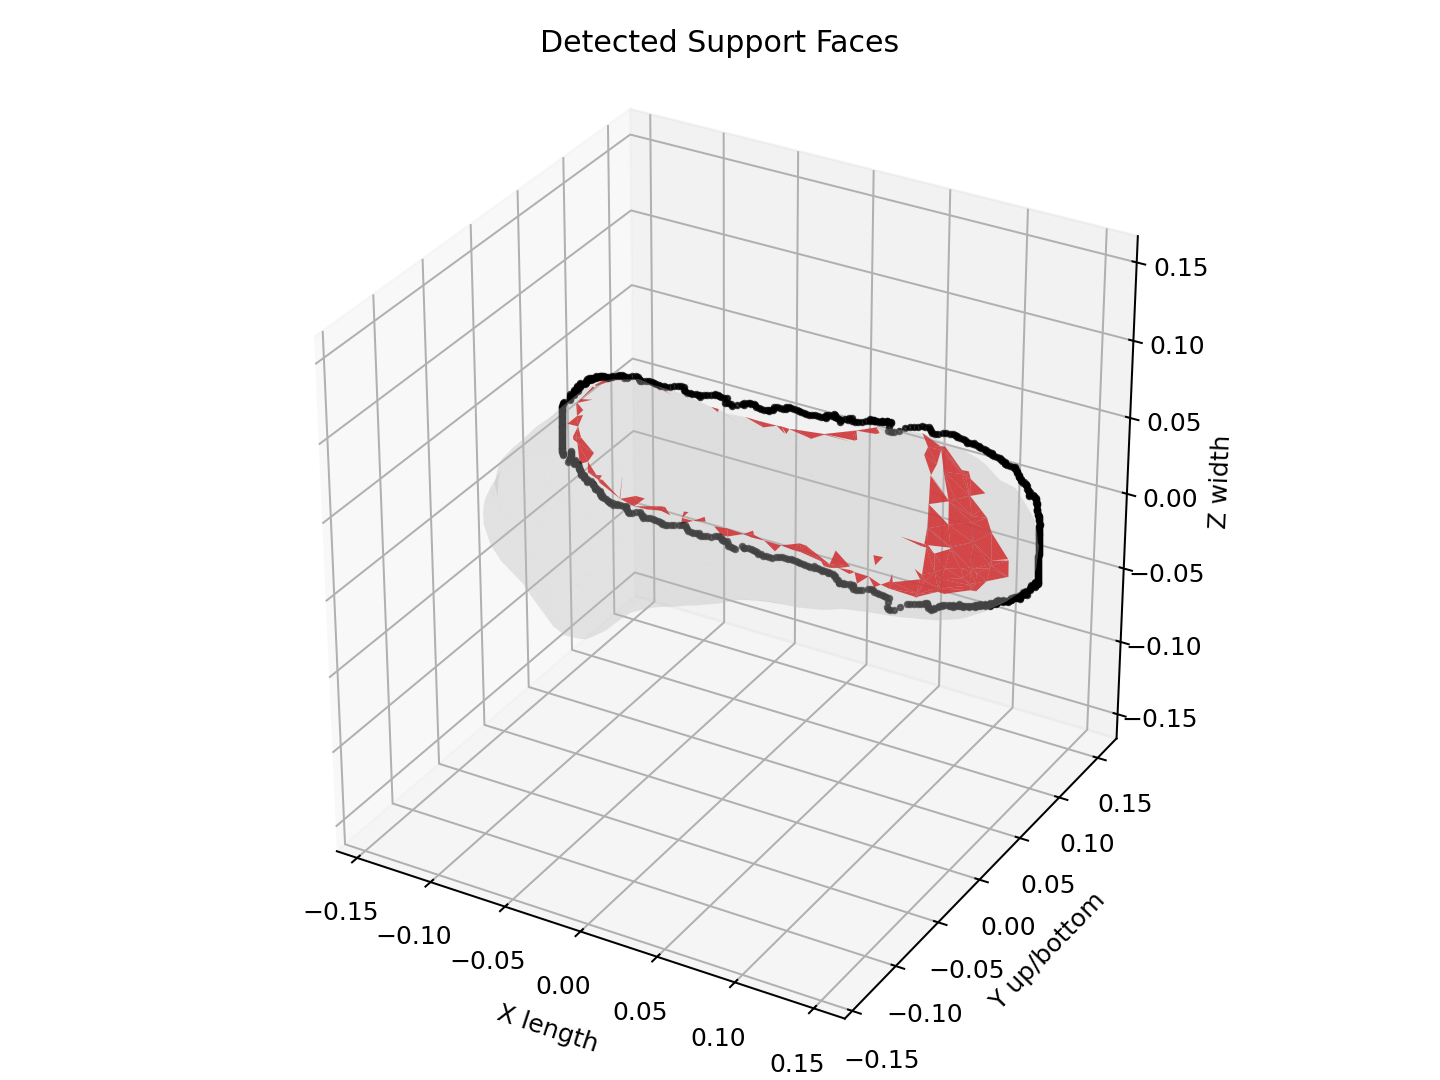

footprint /data/abelde/projects/active/Shell_Gaussian/baselines/GShell/output/support_footbed_analysis/Air-Jordan-1-Mid-Wear-Away-Chicago-Gs_turntable/footprint_centerline.png


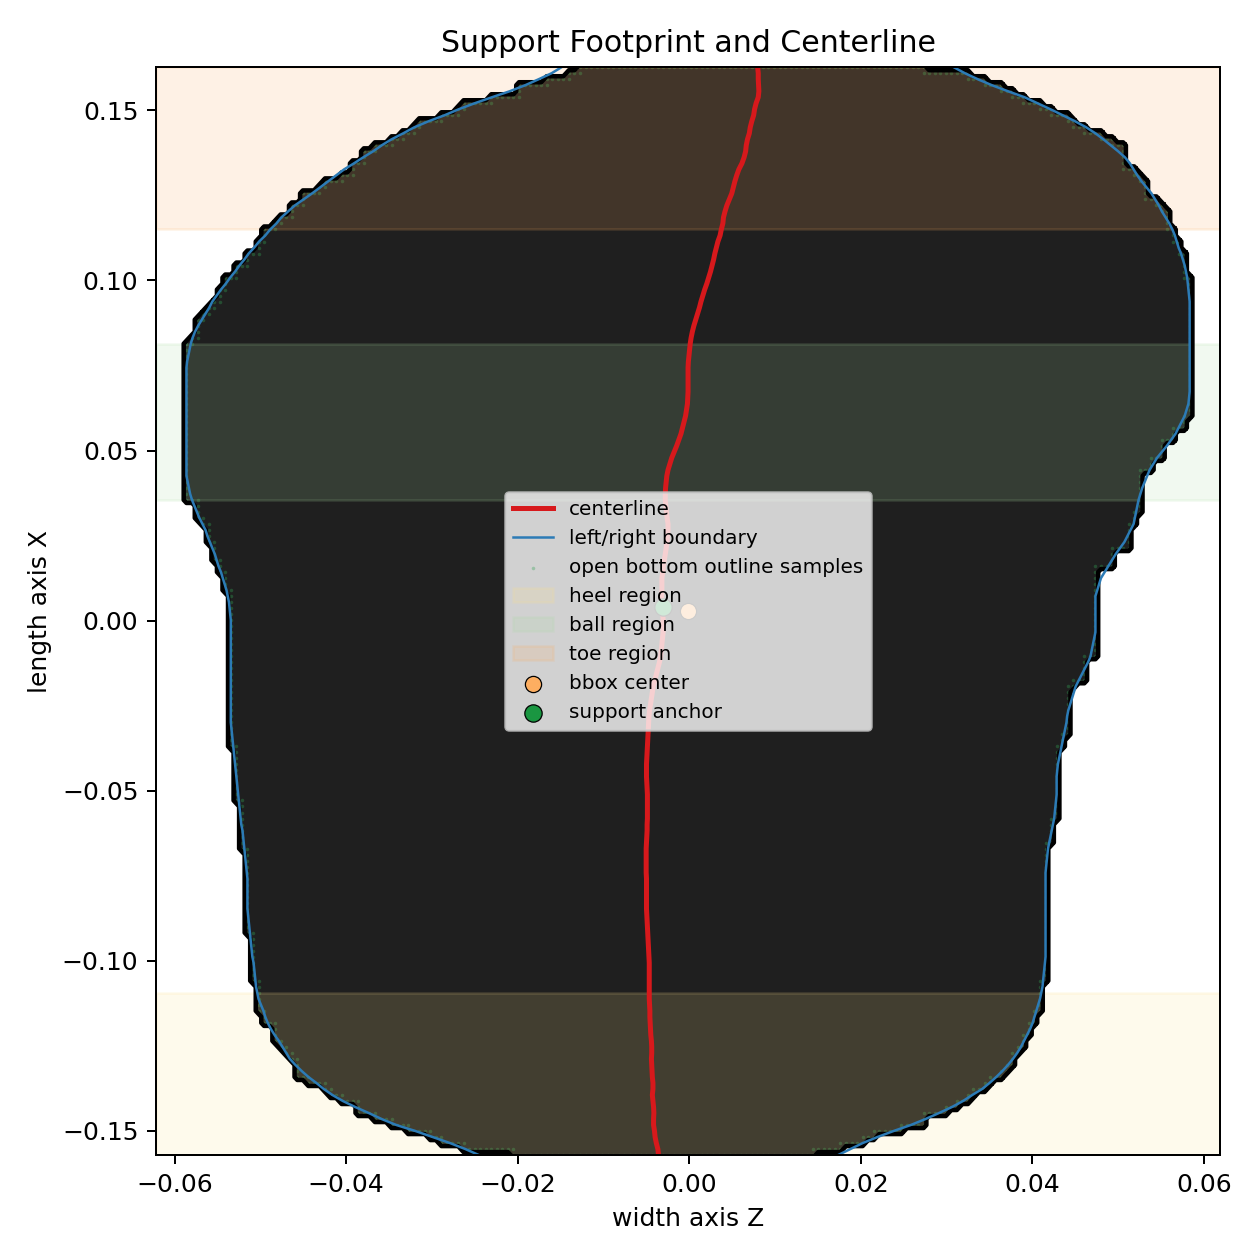

width_profile /data/abelde/projects/active/Shell_Gaussian/baselines/GShell/output/support_footbed_analysis/Air-Jordan-1-Mid-Wear-Away-Chicago-Gs_turntable/width_profile.png


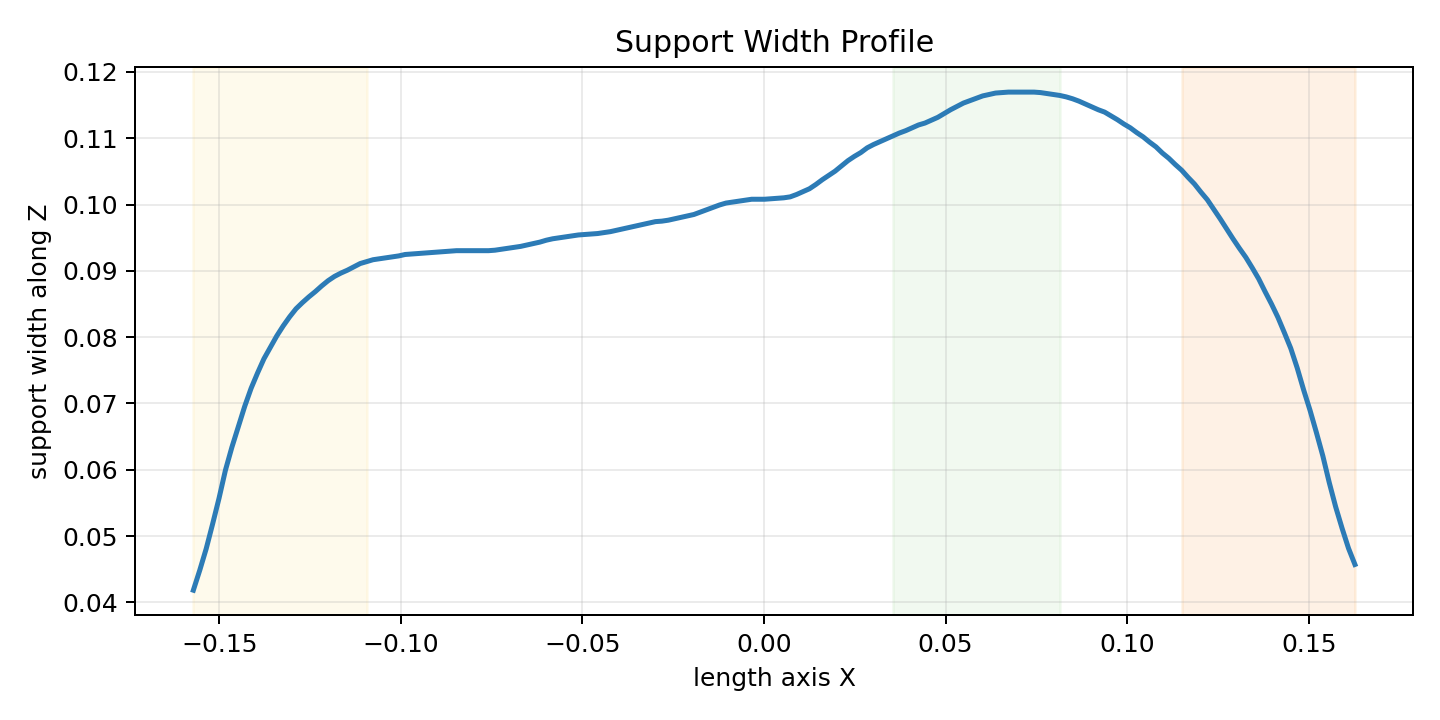

footbed_profile /data/abelde/projects/active/Shell_Gaussian/baselines/GShell/output/support_footbed_analysis/Air-Jordan-1-Mid-Wear-Away-Chicago-Gs_turntable/footbed_profile.png


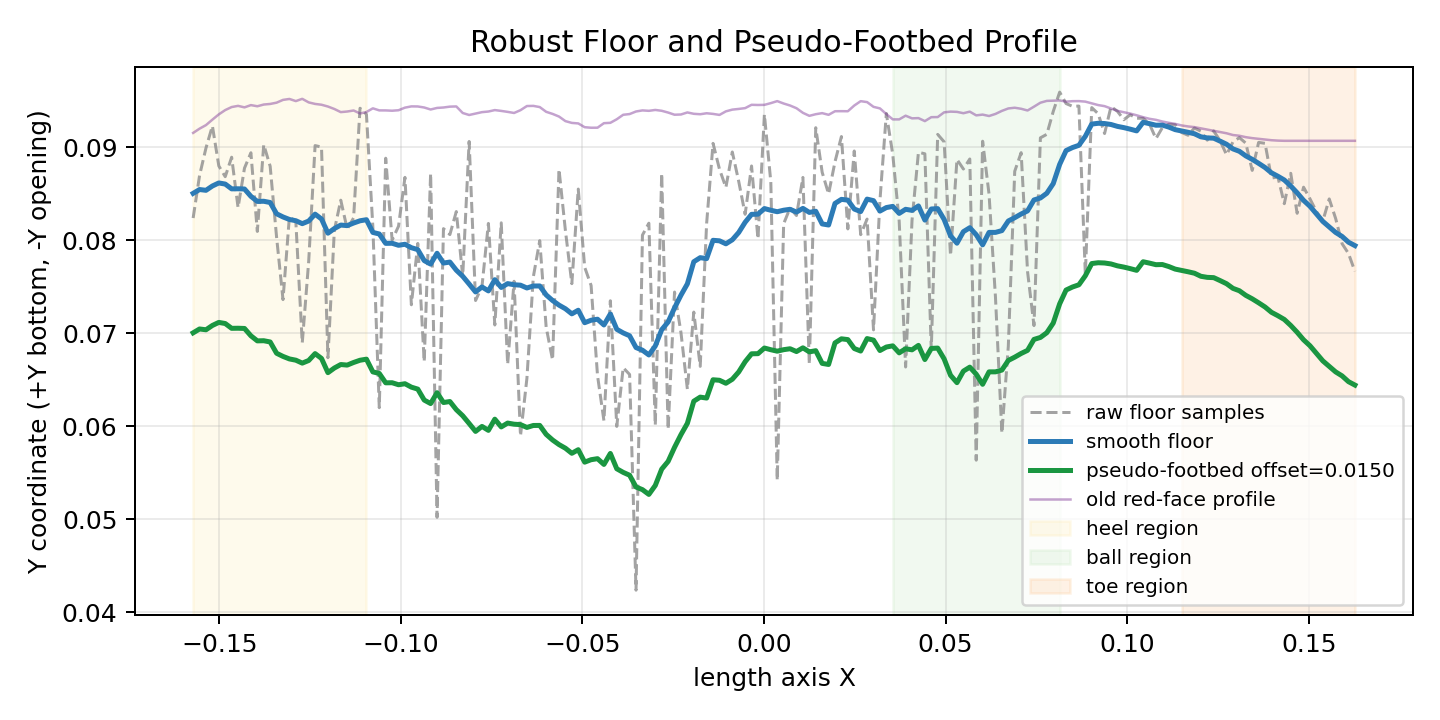

In [6]:
scene_index = 0
display_scene_artifacts(rows[scene_index])

## Strict Contact vs Broad Lower-Sole Band

Use this cell to compare the report's stricter contact-like rule against a broader lower-sole band. For final alignment, the broader lower-sole band is often more useful because it preserves heel/toe footprint information even when the shoe has toe spring or rocker geometry.

In [7]:
scene_name = SHOES[0]
mesh = load_triangle_mesh(mesh_path_for_scene(scene_name, prefer='mesh_watertight'))
open_mesh = load_triangle_mesh(open_mesh_path_for_scene(scene_name))

for q in [0.96, 0.90, 0.80, 0.70]:
    cfg = SupportFootprintConfig(
        bottom_quantile=q,
        fallback_bottom_quantile=max(0.50, q - 0.10),
        grid_resolution=192,
        footbed_offset=CONFIG.footbed_offset,
    )
    fp = extract_support_footprint(mesh, cfg, open_mesh=open_mesh)
    print(
        f'q={q:.2f}: faces={fp.support_face_indices.size:5d}, '
        f'length={fp.length_extent:.4f}, median_width={fp.median_width:.4f}, '
        f'fill={fp.confidence["footprint_fill_fraction"]:.3f}'
    )

q=0.96: faces= 1345, length=0.3199, median_width=0.0969, fill=0.737
q=0.90: faces= 1345, length=0.3199, median_width=0.0969, fill=0.737
q=0.80: faces=  240, length=0.3199, median_width=0.0969, fill=0.737
q=0.70: faces=  414, length=0.3199, median_width=0.0969, fill=0.737


## Next Integration Target

Once the footprint looks reliable across the problematic shoes, the next code change should happen in `build_alignment_from_meshes()`:

- keep the existing bbox path as fallback,
- compute `SupportFootprint` from the shoe mesh,
- replace `shoe_anchor[shoe_width_axis]` with `footprint.suggested_width_anchor`,
- replace or regularize yaw with the support centerline instead of whole-mesh PCA,
- replace the vertical `bottom_coordinate()` anchor with the pseudo-footbed profile near heel/ball regions.

That would move the pipeline from bbox alignment toward support/cavity-aware placement without jumping directly into the full Section 1.4 optimizer.

Honestly: we should stop trying to “get proper faces” directly.

That is the trap.

For 4000 shoes, selecting perfect red sole faces from messy watertight meshes will keep failing because:

```text
some soles have holes
some watertight meshes have fake bulges
some faces point sideways
some soles are curved
some meshes are low quality
some bottoms are broken into weird triangles
```

So the better idea is:

```text
Do not rely on perfect faces.
Build a clean floor surface from the mesh.
```

The black footprint gives us the 2D area:

```text
where the shoe bottom exists in X-Z
```

Then for each point inside that footprint, we estimate:

```text
what is the bottom/floor Y height here?
```

The best method is like this:

```text
1. Take the black footprint.
2. Put a grid over it.
3. For every grid cell inside the footprint:
   look at watertight mesh points/faces near that X-Z location.
4. Estimate the floor height using a robust value, not one triangle.
   Example: median or percentile of bottom-side Y values.
5. Smooth this into a clean floor curve/surface.
6. Use this clean floor for foot placement.
```

So instead of this:

```text
find perfect sole faces -> use them directly
```

we do this:

```text
black footprint + watertight samples -> clean floor height map
```

If we still want red faces for visualization, then after building the clean floor, we can select faces close to that floor. But those faces should be a debug view, not the main source of truth.

The more robust version is ray-based:

```text
For each X-Z grid point inside the footprint:
  shoot a vertical ray through the watertight mesh
  take the first intersection from the bottom side
  that gives the outsole/floor height
```

That is probably the cleanest next step.

So the next thing I would implement is:

```text
support_footprint.py
  add floor height map extraction
  add smoothed pseudo-footbed surface
  stop depending on sparse red faces for floor profile
```

Then Section 1.3 becomes much more solid. The red faces can be ugly, but the floor estimate can still be good.

## Run Full V4 Support-Footbed Analysis

This executable cell runs the same v4 support-footbed script used from the terminal. It uses the trained turntable meshes, the open mesh lower boundary, and writes outputs to `support_footbed_analysis_v4`.


In [ ]:
import os
import runpy
import shlex
import sys
from pathlib import Path

PROJECT_ROOT = Path(globals().get('PROJECT_ROOT', '/data/abelde/projects/active/Shell_Gaussian'))

# Safety guard: set this to True when you actually want to regenerate v4 artifacts.
RUN_SUPPORT_FOOTBED_V4 = True

FOOTSHELL_ROOT = PROJECT_ROOT / 'FootShellGaussian'
GSHELL_ENV = PROJECT_ROOT / 'baselines' / 'GShell' / 'GShell_env'
V4_MESH_ROOT = PROJECT_ROOT / 'baselines' / 'GShell' / 'output' / 'turntable-512-768'
V4_OUTPUT_ROOT = PROJECT_ROOT / 'baselines' / 'GShell' / 'output' / 'support_footbed_analysis_v4'

# Leave this empty to run every trained scene under V4_MESH_ROOT.
# Add exact scene folder names if you only want a subset.
V4_SCENE_NAMES = []

V4_OVERWRITE = True
V4_GRID_RESOLUTION = 192
V4_FOOTBED_OFFSET = 0.015
V4_HEIGHTMAP_MIN_SAMPLES_PER_CELL = 2
V4_HEIGHTMAP_SMOOTH_SIGMA = 1.25
V4_HEIGHTMAP_PROFILE_CLIP = 0.025
V4_FOOTBED_INNER_MARGIN_CELLS = 7
V4_SMOOTH_FOOTBED_WINDOW_FRACTION = 0.18
V4_FOOTBED_HEIGHT_FRACTION = 0.22
V4_OPEN_BOUNDARY_FOOTBED_OFFSET = None
V4_OPEN_BOUNDARY_FOOTBED_OFFSET_RATIO = 0.055
V4_OPEN_BOUNDARY_FOOTBED_OFFSET_MIN = 0.008
V4_OPEN_BOUNDARY_FOOTBED_OFFSET_MAX = 0.022

support_v4_script = FOOTSHELL_ROOT / 'scripts' / 'run_support_footbed_analysis.py'
support_v4_argv = [
    str(support_v4_script),
    '--mesh-root', str(V4_MESH_ROOT),
    '--output-root', str(V4_OUTPUT_ROOT),
    '--grid-resolution', str(V4_GRID_RESOLUTION),
    '--footbed-offset', str(V4_FOOTBED_OFFSET),
    '--heightmap-min-samples-per-cell', str(V4_HEIGHTMAP_MIN_SAMPLES_PER_CELL),
    '--heightmap-smooth-sigma', str(V4_HEIGHTMAP_SMOOTH_SIGMA),
    '--heightmap-profile-clip', str(V4_HEIGHTMAP_PROFILE_CLIP),
    '--footbed-inner-margin-cells', str(V4_FOOTBED_INNER_MARGIN_CELLS),
    '--smooth-footbed-window-fraction', str(V4_SMOOTH_FOOTBED_WINDOW_FRACTION),
    '--footbed-height-fraction', str(V4_FOOTBED_HEIGHT_FRACTION),
    '--open-boundary-footbed-offset-ratio', str(V4_OPEN_BOUNDARY_FOOTBED_OFFSET_RATIO),
    '--open-boundary-footbed-offset-min', str(V4_OPEN_BOUNDARY_FOOTBED_OFFSET_MIN),
    '--open-boundary-footbed-offset-max', str(V4_OPEN_BOUNDARY_FOOTBED_OFFSET_MAX),
]
if V4_OPEN_BOUNDARY_FOOTBED_OFFSET is not None:
    support_v4_argv += ['--open-boundary-footbed-offset', str(V4_OPEN_BOUNDARY_FOOTBED_OFFSET)]
for scene_name in V4_SCENE_NAMES:
    support_v4_argv += ['--scene', scene_name]
if V4_OVERWRITE:
    support_v4_argv += ['--overwrite']

shell_equivalent = [str(GSHELL_ENV / 'bin' / 'python')] + support_v4_argv
print(' '.join(shlex.quote(part) for part in shell_equivalent))
print('v4 output root:', V4_OUTPUT_ROOT)

if RUN_SUPPORT_FOOTBED_V4:
    old_argv = sys.argv[:]
    try:
        sys.argv = support_v4_argv
        runpy.run_path(str(support_v4_script), run_name='__main__')
    finally:
        sys.argv = old_argv
else:
    print('Set RUN_SUPPORT_FOOTBED_V4 = True, then execute this cell to run v4 support-footbed analysis.')


## Pseudo-Last Cross-Section Mask Debugger

This section visualizes the exact pseudo-last cross-section labels used by `PseudoLastPriorLoss`.
It shows which points are treated as empty cavity, lower sole/support material, plantar/bottom-adjacent support, and lower sidewall support.

The first plot is a dense Y-Z slice classifier, so it explains the geometric rule. The second plot shows the actual tet-grid vertices selected for the mSDF keep loss, so it explains what training really touches.


In [ ]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D

PROJECT_ROOT = Path('/data/abelde/projects/active/Shell_Gaussian')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import importlib
import FootShellGaussian.foot_prior.pseudo_last_loss as pseudo_last_loss_module
pseudo_last_loss_module = importlib.reload(pseudo_last_loss_module)
PseudoLastPriorConfig = pseudo_last_loss_module.PseudoLastPriorConfig
PseudoLastPriorLoss = pseudo_last_loss_module.PseudoLastPriorLoss

PSEUDO_LAST_ROOT = PROJECT_ROOT / 'FootShellGaussian/output/pseudo_last_section_loft'
PSEUDO_LAST_SHOE = 'Air-Jordan-1-Mid-Wear-Away-Chicago-Gs'
PSEUDO_LAST_DIR = PSEUDO_LAST_ROOT / PSEUDO_LAST_SHOE
PSEUDO_LAST_SDF_PATH = PSEUDO_LAST_DIR / 'pseudo_last_sdf.npz'
PSEUDO_LAST_SECTIONS_PATH = PSEUDO_LAST_DIR / 'pseudo_last_sections.npz'
TRAIN_CONFIG_PATH = PROJECT_ROOT / 'FootShellGaussian/configs/shoes_mc_pseudolast_xsec_gt_512.json'

assert PSEUDO_LAST_SDF_PATH.exists(), PSEUDO_LAST_SDF_PATH
assert PSEUDO_LAST_SECTIONS_PATH.exists(), PSEUDO_LAST_SECTIONS_PATH
assert TRAIN_CONFIG_PATH.exists(), TRAIN_CONFIG_PATH

with TRAIN_CONFIG_PATH.open('r') as f:
    train_cfg = json.load(f)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pseudo_cfg = PseudoLastPriorConfig(
    sdf_path=str(PSEUDO_LAST_SDF_PATH),
    sections_path=str(PSEUDO_LAST_SECTIONS_PATH),
    prior_mode='cross_section',
    xsec_x_slices=int(train_cfg.get('pseudo_last_xsec_x_slices', 64)),
    xsec_y_samples=int(train_cfg.get('pseudo_last_xsec_y_samples', 96)),
    xsec_z_samples=int(train_cfg.get('pseudo_last_xsec_z_samples', 96)),
    xsec_max_points=int(train_cfg.get('pseudo_last_xsec_max_points', 49152)),
    xsec_grid_max_points=int(train_cfg.get('pseudo_last_xsec_grid_max_points', 0)),
    xsec_material_margin=float(train_cfg.get('pseudo_last_xsec_material_margin', 0.005)),
    xsec_empty_margin=float(train_cfg.get('pseudo_last_xsec_empty_margin', 0.005)),
    xsec_surface_band=float(train_cfg.get('pseudo_last_xsec_surface_band', 0.003)),
    xsec_sole_depth=float(train_cfg.get('pseudo_last_xsec_sole_depth', 0.025)),
    xsec_plantar_h_ratio=float(train_cfg.get('pseudo_last_xsec_plantar_h_ratio', 0.12)),
    xsec_lower_wall_h_ratio=float(train_cfg.get('pseudo_last_xsec_lower_wall_h_ratio', 0.45)),
    xsec_ignore_high_h_ratio=float(train_cfg.get('pseudo_last_xsec_ignore_high_h_ratio', 0.85)),
    xsec_support_lateral_pad=float(train_cfg.get('pseudo_last_xsec_support_lateral_pad', 0.05)),
    xsec_msdf_margin=float(train_cfg.get('pseudo_last_xsec_msdf_margin', 0.005)),
    xsec_last_surface_points=int(train_cfg.get('pseudo_last_xsec_last_surface_points', 8192)),
    xsec_material_weight=float(train_cfg.get('pseudo_last_xsec_material_weight', 20.0)),
    xsec_empty_weight=float(train_cfg.get('pseudo_last_xsec_empty_weight', 10.0)),
    xsec_surface_weight=float(train_cfg.get('pseudo_last_xsec_surface_weight', 2.0)),
    xsec_msdf_keep_weight=float(train_cfg.get('pseudo_last_xsec_msdf_keep_weight', 0.01)),
)

pseudo_prior = PseudoLastPriorLoss(pseudo_cfg, device=device)
PSEUDO_LAST_DEBUGGER_VERSION = 'xsec_cap_v3_positive_inside_cavity'
sections_npz = np.load(PSEUDO_LAST_SECTIONS_PATH, allow_pickle=True)

print('Loaded pseudo-last mask debugger')
print('shoe        :', PSEUDO_LAST_SHOE)
print('device      :', device)
print('SDF         :', PSEUDO_LAST_SDF_PATH)
print('sections    :', PSEUDO_LAST_SECTIONS_PATH)
print('x range     :', float(pseudo_prior.section_x[0]), 'to', float(pseudo_prior.section_x[-1]))
print('pool counts :')
for key in [
    'xsec_pool_total_count',
    'xsec_empty_pool_count',
    'xsec_material_pool_count',
    'xsec_surface_pool_count',
    'xsec_sole_pool_count',
    'xsec_plantar_pool_count',
    'xsec_sidewall_pool_count',
]:
    print(f'  {key:30s}', pseudo_prior.label_stats.get(key))


In [ ]:
def _to_numpy(tensor):
    if torch.is_tensor(tensor):
        return tensor.detach().cpu().numpy()
    return np.asarray(tensor)


def classify_yz_slice(prior, x_value, ny=220, nz=220):
    """Classify a dense Y-Z slice at one X coordinate using the same code as training."""
    dtype = prior.section_x.dtype
    dev = prior.section_x.device
    x_t = torch.tensor([x_value], dtype=dtype, device=dev)

    center = prior._interp_1d(x_t, prior.center_z)[0]
    half_width = prior._interp_1d(x_t, prior.half_width).clamp(min=1e-6)[0]
    support_half = prior._interp_1d(x_t, prior.support_half_width).clamp(min=1e-6)[0]
    height = prior._interp_1d(x_t, prior.section_height).clamp(min=1e-6)[0]

    z_min = center - support_half * (1.0 + float(prior.config.xsec_support_lateral_pad) + 0.10)
    z_max = center + support_half * (1.0 + float(prior.config.xsec_support_lateral_pad) + 0.10)
    z_axis = torch.linspace(z_min, z_max, nz, dtype=dtype, device=dev)

    xz_for_bottom = torch.stack([
        torch.full_like(z_axis, x_t[0]),
        torch.zeros_like(z_axis),
        z_axis,
    ], dim=-1)
    bottom_line = prior._interp_bottom_y(
        xz_for_bottom,
        center=torch.full_like(z_axis, center),
        half_width=torch.full_like(z_axis, half_width),
    )

    # Use the same vertical convention as _build_cross_section_pool(): include below-bottom
    # sole candidates and the lower/high portion used by the classifier.
    y_min = bottom_line.min() - height * float(prior.config.xsec_ignore_high_h_ratio) * 1.08
    y_max = bottom_line.max() + float(prior.config.xsec_sole_depth) * 1.25
    y_axis = torch.linspace(y_min, y_max, ny, dtype=dtype, device=dev)
    yy, zz = torch.meshgrid(y_axis, z_axis, indexing='ij')
    points = torch.stack([
        torch.full_like(yy, x_t[0]),
        yy,
        zz,
    ], dim=-1).reshape(-1, 3)

    last_cavity = prior._query_last_cavity_field_chunked(points)
    labels = prior._classify_points(points, last_cavity)

    label_img = torch.zeros(points.shape[0], dtype=torch.long, device=dev)
    label_img[labels['empty_mask']] = 1
    label_img[labels['sole_mask']] = 2
    label_img[labels['plantar_mask']] = 3
    label_img[labels['sidewall_mask']] = 4

    return {
        'x': float(x_value),
        'y_axis': _to_numpy(y_axis),
        'z_axis': _to_numpy(z_axis),
        'labels': _to_numpy(label_img.reshape(ny, nz)),
        'last_cavity': _to_numpy(last_cavity.reshape(ny, nz)),
        'bottom_y': _to_numpy(bottom_line),
        'center_z': float(center.detach().cpu()),
        'half_width': float(half_width.detach().cpu()),
        'support_half_width': float(support_half.detach().cpu()),
        'height': float(height.detach().cpu()),
    }


label_colors = [
    '#f7f7f7',  # background / ignored
    '#4f9cf9',  # empty inside last
    '#111111',  # sole support/material
    '#f59e0b',  # plantar/bottom-adjacent support
    '#22c55e',  # lower sidewall support
]
label_names = ['ignored', 'empty cavity', 'sole material', 'plantar support', 'lower sidewall']
cmap = ListedColormap(label_colors)
norm = BoundaryNorm(np.arange(-0.5, 5.5, 1.0), cmap.N)


def plot_cross_section_masks(prior, sections_data, s_values=(0.05, 0.20, 0.40, 0.60, 0.80, 0.95), ny=220, nz=220):
    x0 = float(prior.section_x[0].detach().cpu())
    x1 = float(prior.section_x[-1].detach().cpu())
    x_grid = np.asarray(sections_data['x'], dtype=np.float32)
    sections = np.asarray(sections_data['sections'], dtype=np.float32)
    bottom_sections = np.asarray(sections_data['bottom_sections'], dtype=np.float32)

    ncols = min(3, len(s_values))
    nrows = int(np.ceil(len(s_values) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.2 * nrows), squeeze=False)

    for ax, s in zip(axes.reshape(-1), s_values):
        x_value = x0 + float(s) * (x1 - x0)
        out = classify_yz_slice(prior, x_value, ny=ny, nz=nz)
        y_axis = out['y_axis']
        z_axis = out['z_axis']
        labels = out['labels']
        last_cavity = out['last_cavity']

        # Shoe coordinate convention uses -Y as physical up. Plotting -Y makes
        # lower sole/support regions appear lower in the figure.
        y_vis_axis = -y_axis[::-1]
        labels_vis = labels[::-1, :]
        last_cavity_vis = last_cavity[::-1, :]

        ax.imshow(
            labels_vis,
            origin='lower',
            extent=[z_axis[0], z_axis[-1], y_vis_axis[0], y_vis_axis[-1]],
            cmap=cmap,
            norm=norm,
            interpolation='nearest',
            alpha=0.78,
            aspect='auto',
        )
        ax.contour(z_axis, y_vis_axis, last_cavity_vis, levels=[0.0], colors='black', linewidths=1.4)
        ax.plot(z_axis, -out['bottom_y'], color='#06b6d4', linewidth=1.4, label='bottom curve')

        nearest = int(np.argmin(np.abs(x_grid - x_value)))
        sec = sections[nearest]
        bot = bottom_sections[nearest]
        finite_sec = np.isfinite(sec).all(axis=1)
        finite_bot = np.isfinite(bot).all(axis=1)
        ax.plot(sec[finite_sec, 2], -sec[finite_sec, 1], color='black', linewidth=1.0, alpha=0.8, label='last section')
        ax.plot(bot[finite_bot, 2], -bot[finite_bot, 1], color='#0891b2', linewidth=1.0, alpha=0.9, label='stored bottom')

        center = out['center_z']
        support_half = out['support_half_width']
        ax.axvline(center - support_half, color='#64748b', linestyle='--', linewidth=0.9)
        ax.axvline(center + support_half, color='#64748b', linestyle='--', linewidth=0.9)
        ax.set_title(f's={s:.2f}, x={x_value:.4f}')
        ax.set_xlabel('Z / width direction')
        ax.set_ylabel('visual vertical (-Y; physical up)')

    for ax in axes.reshape(-1)[len(s_values):]:
        ax.axis('off')

    legend_handles = [
        Line2D([0], [0], marker='s', color='none', markerfacecolor=color, markersize=10, label=name)
        for color, name in zip(label_colors, label_names)
    ]
    legend_handles.extend([
        Line2D([0], [0], color='black', linewidth=1.4, label='last SDF = 0 / section'),
        Line2D([0], [0], color='#06b6d4', linewidth=1.4, label='bottom curve'),
        Line2D([0], [0], color='#64748b', linestyle='--', linewidth=0.9, label='support left/right'),
    ])
    fig.legend(handles=legend_handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(f'Pseudo-last cross-section masks: {PSEUDO_LAST_SHOE}', y=1.02, fontsize=14)
    fig.tight_layout()
    return fig


fig = plot_cross_section_masks(pseudo_prior, sections_npz)
plt.show()


Tet grid: /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/data/tets/128_tets.npz
Total grid vertices: 277410
Selected grid mSDF candidates: 229
Grid stats:
  xsec_grid_msdf_candidate_count       229
  xsec_grid_msdf_candidate_fraction    0.0008254929562099278
  xsec_grid_sole_candidate_count       190
  xsec_grid_plantar_candidate_count    2
  xsec_grid_sidewall_candidate_count   39
Selected grid h_norm percentiles:
  p  0: -0.9721
  p  1: -0.9721
  p  5: -0.7633
  p 50: -0.1948
  p 95:  0.3229
  p 99:  0.3926
  p100:  0.4018
Note: very negative h_norm means the candidate is far below the pseudo-last bottom.


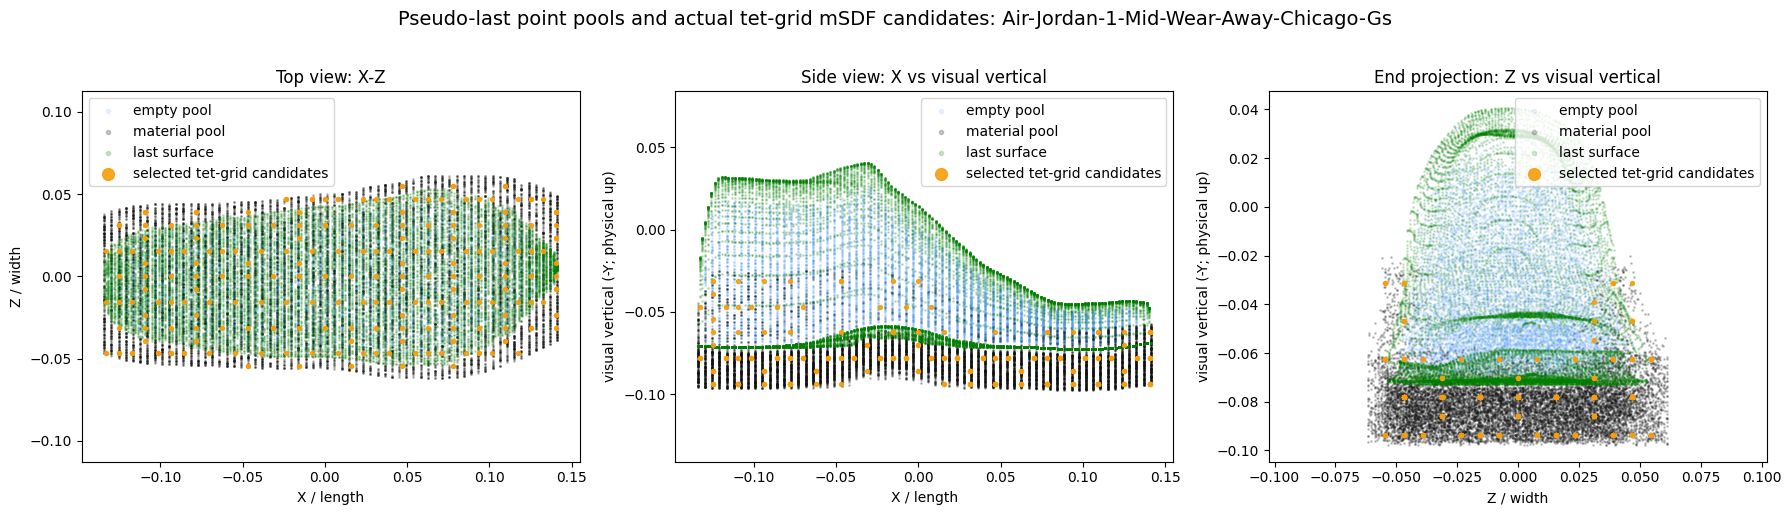

In [11]:
def load_training_tet_grid(config_path, project_root=PROJECT_ROOT):
    """Load the same initial tet-grid vertex coordinates used by GShellTetsGeometry."""
    with Path(config_path).open('r') as f:
        cfg = json.load(f)
    grid_res = int(cfg.get('gshell_grid', 128))
    mesh_scale = float(cfg.get('mesh_scale', 1.0))
    boxscale = np.asarray(cfg.get('boxscale', [1.0, 1.0, 1.0]), dtype=np.float32).reshape(1, 3)
    tet_candidates = [
        project_root / f'FootShellGaussian/data/tets/{grid_res}_tets.npz',
        project_root / f'baselines/GShell/data/tets/{grid_res}_tets.npz',
        project_root / f'data/tets/{grid_res}_tets.npz',
    ]
    tets_path = next((candidate for candidate in tet_candidates if candidate.exists()), None)
    if tets_path is None:
        raise FileNotFoundError(f'Could not find {grid_res}_tets.npz in: {tet_candidates}')
    tets = np.load(tets_path)
    verts = np.asarray(tets['vertices'], dtype=np.float32)
    verts = verts - verts.mean(axis=0, keepdims=True)
    verts = verts * mesh_scale * boxscale
    return verts, tets_path, cfg


grid_verts_np, tets_path, train_cfg_loaded = load_training_tet_grid(TRAIN_CONFIG_PATH)
grid_verts = torch.as_tensor(grid_verts_np, dtype=torch.float32, device=device)
grid_stats = pseudo_prior.precompute_grid_keep_weights(grid_verts)

grid_indices = _to_numpy(pseudo_prior.material_grid_indices).astype(np.int64)
grid_weights = _to_numpy(pseudo_prior.material_grid_weights)
grid_candidates = grid_verts_np[grid_indices] if grid_indices.size else np.zeros((0, 3), dtype=np.float32)

print('Tet grid:', tets_path)
print('Total grid vertices:', grid_verts_np.shape[0])
print('Selected grid mSDF candidates:', grid_candidates.shape[0])
print('Grid stats:')
for key in [
    'xsec_grid_msdf_candidate_count',
    'xsec_grid_msdf_candidate_fraction',
    'xsec_grid_sole_candidate_count',
    'xsec_grid_plantar_candidate_count',
    'xsec_grid_sidewall_candidate_count',
]:
    print(f'  {key:36s}', grid_stats.get(key))

if grid_indices.size:
    grid_coords = pseudo_prior.section_coordinates(grid_verts)
    selected_h_norm = _to_numpy(grid_coords['h_norm'][pseudo_prior.material_grid_indices])
    print('Selected grid h_norm percentiles:')
    for q, value in zip([0, 1, 5, 50, 95, 99, 100], np.percentile(selected_h_norm, [0, 1, 5, 50, 95, 99, 100])):
        print(f'  p{q:>3}: {value: .4f}')
    print('Note: very negative h_norm means the candidate is far below the pseudo-last bottom.')

# Show the dense sampled pools and the actual sparse tet-grid candidates side by side.
material_pool = _to_numpy(pseudo_prior.material_points)
empty_pool = _to_numpy(pseudo_prior.empty_points)
surface_pool = _to_numpy(pseudo_prior.surface_points)

rng = np.random.default_rng(7)
def sample_np(arr, max_n):
    if arr.shape[0] <= max_n:
        return arr
    return arr[rng.choice(arr.shape[0], size=max_n, replace=False)]

material_s = sample_np(material_pool, 12000)
empty_s = sample_np(empty_pool, 12000)
surface_s = sample_np(surface_pool, 12000)
grid_s = sample_np(grid_candidates, 12000)
grid_w_s = grid_weights[:grid_s.shape[0]] if grid_s.shape[0] == grid_weights.shape[0] else None

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Top view: length vs width.
ax = axes[0]
ax.scatter(empty_s[:, 0], empty_s[:, 2], s=1.0, c='#4f9cf9', alpha=0.12, label='empty pool')
ax.scatter(material_s[:, 0], material_s[:, 2], s=1.0, c='#111111', alpha=0.22, label='material pool')
ax.scatter(surface_s[:, 0], surface_s[:, 2], s=1.0, c='#008000', alpha=0.20, label='last surface')
if grid_s.shape[0]:
    ax.scatter(grid_s[:, 0], grid_s[:, 2], s=8.0, c='#f59e0b', alpha=0.90, label='selected tet-grid candidates')
ax.set_title('Top view: X-Z')
ax.set_xlabel('X / length')
ax.set_ylabel('Z / width')
ax.legend(markerscale=3)
ax.axis('equal')

# Side view: length vs vertical.
ax = axes[1]
ax.scatter(empty_s[:, 0], -empty_s[:, 1], s=1.0, c='#4f9cf9', alpha=0.12, label='empty pool')
ax.scatter(material_s[:, 0], -material_s[:, 1], s=1.0, c='#111111', alpha=0.22, label='material pool')
ax.scatter(surface_s[:, 0], -surface_s[:, 1], s=1.0, c='#008000', alpha=0.20, label='last surface')
if grid_s.shape[0]:
    ax.scatter(grid_s[:, 0], -grid_s[:, 1], s=8.0, c='#f59e0b', alpha=0.90, label='selected tet-grid candidates')
ax.set_title('Side view: X vs visual vertical')
ax.set_xlabel('X / length')
ax.set_ylabel('visual vertical (-Y; physical up)')
ax.legend(markerscale=3)
ax.axis('equal')

# Cross-width/vertical projection.
ax = axes[2]
ax.scatter(empty_s[:, 2], -empty_s[:, 1], s=1.0, c='#4f9cf9', alpha=0.10, label='empty pool')
ax.scatter(material_s[:, 2], -material_s[:, 1], s=1.0, c='#111111', alpha=0.20, label='material pool')
ax.scatter(surface_s[:, 2], -surface_s[:, 1], s=1.0, c="#008000", alpha=0.16, label='last surface')
if grid_s.shape[0]:
    ax.scatter(grid_s[:, 2], -grid_s[:, 1], s=8.0, c='#f59e0b', alpha=0.90, label='selected tet-grid candidates')
ax.set_title('End projection: Z vs visual vertical')
ax.set_xlabel('Z / width')
ax.set_ylabel('visual vertical (-Y; physical up)')
ax.legend(markerscale=3)
ax.axis('equal')

fig.suptitle(f'Pseudo-last point pools and actual tet-grid mSDF candidates: {PSEUDO_LAST_SHOE}', y=1.02, fontsize=14)
fig.tight_layout()
plt.show()


## Pseudo-Last Prior Audit: What The Loss Is Actually Supervising

This section audits the current pseudo-last loss before changing the code. It checks three questions:

1. Are the tet-grid mSDF candidates close to the pseudo-last bottom, or are they far below it?
2. Which categories dominate the sampled supervision: empty, sole, plantar, sidewall, or surface?
3. Which parts of the loss are already satisfied, and which ones are actually pushing the model?


In [ ]:
# This cell assumes the previous Pseudo-Last Cross-Section Mask Debugger section has been run.
# If not, run cells 19-21 first. Cell 19 force-reloads pseudo_last_loss.py.
import pandas as pd

assert 'pseudo_prior' in globals(), 'Run the pseudo-last mask debugger setup cell first.'
assert 'grid_verts' in globals(), 'Run the tet-grid candidate visualization cell first.'
assert globals().get('PSEUDO_LAST_DEBUGGER_VERSION') == 'xsec_cap_v3_positive_inside_cavity', 'Run cell 19 first; the notebook is using stale pseudo_prior variables.'

with torch.no_grad():
    last_cavity_grid = pseudo_prior._query_last_cavity_field_chunked(grid_verts)
    labels_grid = pseudo_prior._classify_points(grid_verts, last_cavity_grid)
    coords_grid = pseudo_prior.section_coordinates(grid_verts)

    current_mask = labels_grid['material_weight'] > 0
    current_idx = torch.nonzero(current_mask, as_tuple=False).reshape(-1)

    # Reconstruct the old bug for comparison: the old sole selector had no finite
    # depth limit below the pseudo-last bottom. This is NOT used by training now;
    # it is only here to show what we fixed.
    within_length = (coords_grid['s_raw'] >= 0.0) & (coords_grid['s_raw'] <= 1.0)
    within_support = torch.abs(coords_grid['u_support']) <= (1.0 + float(pseudo_prior.config.xsec_support_lateral_pad))
    low_enough = coords_grid['h_norm'] <= float(pseudo_prior.config.xsec_ignore_high_h_ratio)
    outside_cavity = last_cavity_grid < -float(pseudo_prior.config.xsec_surface_band)
    legacy_uncapped_sole_mask = (
        within_length
        & within_support
        & low_enough
        & outside_cavity
        & (coords_grid['h'] < 0.0)
    )
    legacy_uncapped_mask = legacy_uncapped_sole_mask | labels_grid['plantar_mask'] | labels_grid['sidewall_mask']
    legacy_uncapped_idx = torch.nonzero(legacy_uncapped_mask, as_tuple=False).reshape(-1)

    def summarize_indices(name, idx):
        if idx.numel() == 0:
            return {'name': name, 'count': 0}
        h = _to_numpy(coords_grid['h'][idx])
        h_norm = _to_numpy(coords_grid['h_norm'][idx])
        s = _to_numpy(coords_grid['s_raw'][idx])
        u_support = _to_numpy(coords_grid['u_support'][idx])
        cavity = _to_numpy(last_cavity_grid[idx])
        return {
            'name': name,
            'count': int(idx.numel()),
            'h_min': float(np.min(h)),
            'h_p01': float(np.percentile(h, 1)),
            'h_p50': float(np.percentile(h, 50)),
            'h_p99': float(np.percentile(h, 99)),
            'h_max': float(np.max(h)),
            'h_norm_p50': float(np.percentile(h_norm, 50)),
            's_min': float(np.min(s)),
            's_max': float(np.max(s)),
            'abs_u_support_p99': float(np.percentile(np.abs(u_support), 99)),
            'last_cavity_p50': float(np.percentile(cavity, 50)),
        }

    audit_rows = [
        summarize_indices('legacy uncapped selector (old bug)', legacy_uncapped_idx),
        summarize_indices('current fixed selector used by training', current_idx),
    ]

audit_df = pd.DataFrame(audit_rows)
display(audit_df)

print('Current fixed grid category counts:')
print('  sole    :', int(labels_grid['sole_mask'].sum().detach().cpu()))
print('  plantar :', int(labels_grid['plantar_mask'].sum().detach().cpu()))
print('  sidewall:', int(labels_grid['sidewall_mask'].sum().detach().cpu()))
print('  material:', int(current_mask.sum().detach().cpu()))
print()
print('Legacy uncapped candidate count:', int(legacy_uncapped_idx.numel()))
print('Current fixed candidate count  :', int(current_idx.numel()))
print('Far-below fixed candidates     :', int((coords_grid['h'][current_idx] < -float(pseudo_prior.config.xsec_sole_depth)).sum().detach().cpu()))


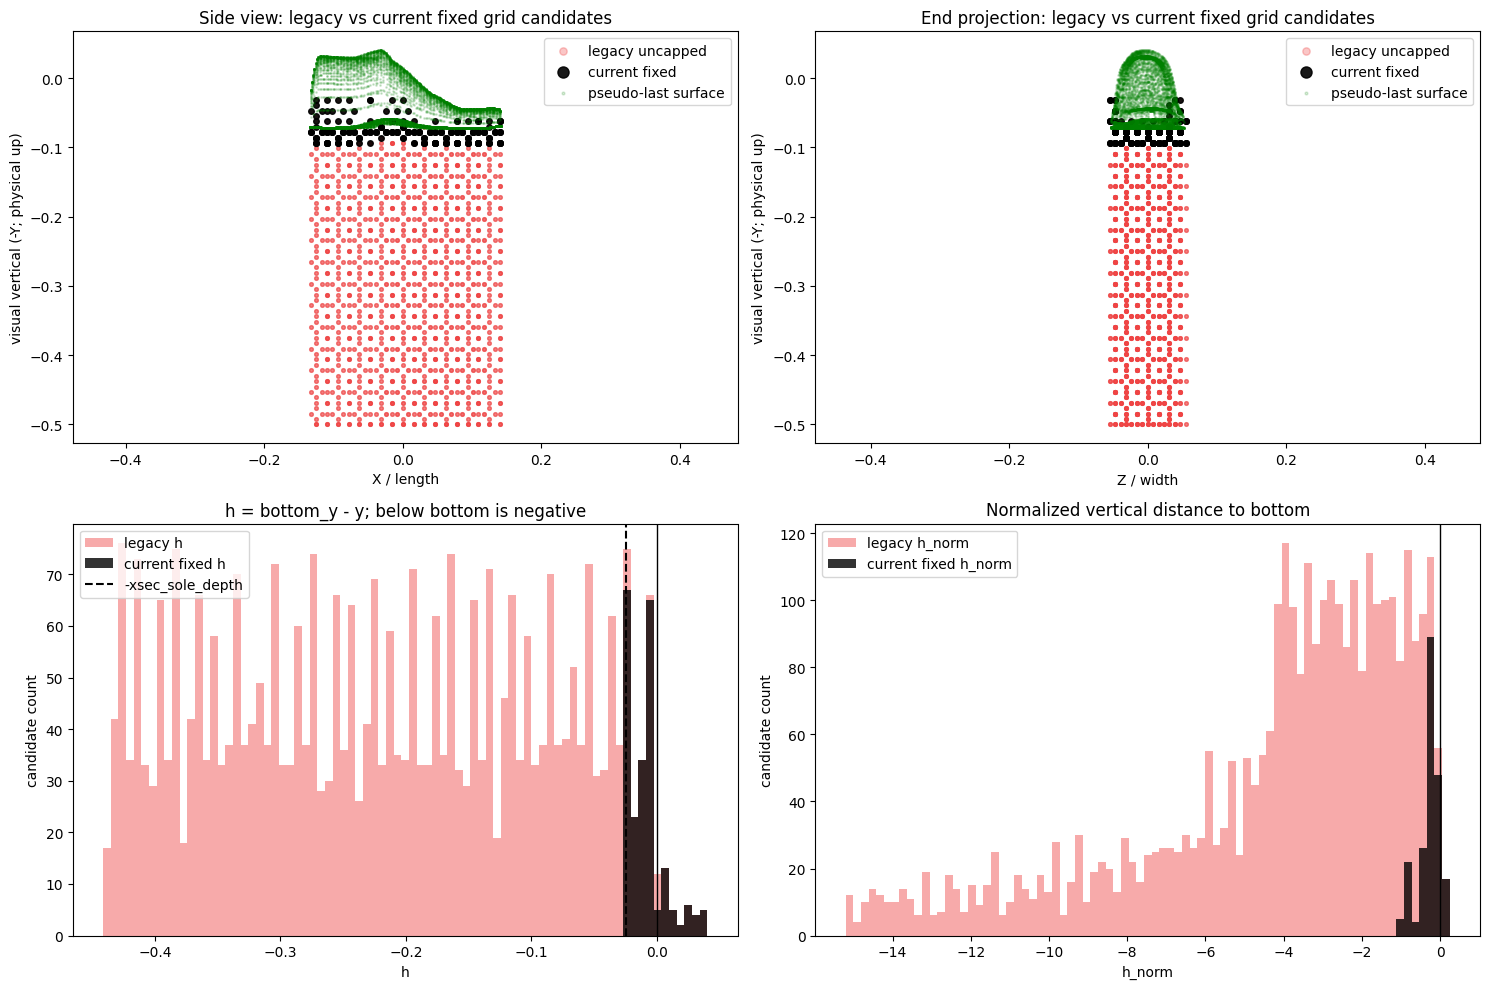

In [13]:
# Visualize legacy-uncapped vs current fixed grid candidates and their vertical distance from the pseudo-last bottom.
legacy_pts = _to_numpy(grid_verts[legacy_uncapped_idx]) if legacy_uncapped_idx.numel() else np.zeros((0, 3), dtype=np.float32)
current_pts = _to_numpy(grid_verts[current_idx]) if current_idx.numel() else np.zeros((0, 3), dtype=np.float32)
legacy_h = _to_numpy(coords_grid['h'][legacy_uncapped_idx]) if legacy_uncapped_idx.numel() else np.array([])
current_h = _to_numpy(coords_grid['h'][current_idx]) if current_idx.numel() else np.array([])
legacy_hn = _to_numpy(coords_grid['h_norm'][legacy_uncapped_idx]) if legacy_uncapped_idx.numel() else np.array([])
current_hn = _to_numpy(coords_grid['h_norm'][current_idx]) if current_idx.numel() else np.array([])

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

ax = axes[0, 0]
if legacy_pts.shape[0]:
    ax.scatter(legacy_pts[:, 0], -legacy_pts[:, 1], s=7, c='#ef4444', alpha=0.30, label='legacy uncapped')
if current_pts.shape[0]:
    ax.scatter(current_pts[:, 0], -current_pts[:, 1], s=16, c='#000000', alpha=0.90, label='current fixed')
surf = _to_numpy(pseudo_prior.surface_points)
surf_s = surf[np.random.default_rng(4).choice(surf.shape[0], min(surf.shape[0], 10000), replace=False)]
ax.scatter(surf_s[:, 0], -surf_s[:, 1], s=1, c='#008000', alpha=0.16, label='pseudo-last surface')
ax.set_title('Side view: legacy vs current fixed grid candidates')
ax.set_xlabel('X / length')
ax.set_ylabel('visual vertical (-Y; physical up)')
ax.legend(markerscale=2)
ax.axis('equal')

ax = axes[0, 1]
if legacy_pts.shape[0]:
    ax.scatter(legacy_pts[:, 2], -legacy_pts[:, 1], s=7, c='#ef4444', alpha=0.30, label='legacy uncapped')
if current_pts.shape[0]:
    ax.scatter(current_pts[:, 2], -current_pts[:, 1], s=16, c='#000000', alpha=0.90, label='current fixed')
ax.scatter(surf_s[:, 2], -surf_s[:, 1], s=1, c='#008000', alpha=0.16, label='pseudo-last surface')
ax.set_title('End projection: legacy vs current fixed grid candidates')
ax.set_xlabel('Z / width')
ax.set_ylabel('visual vertical (-Y; physical up)')
ax.legend(markerscale=2)
ax.axis('equal')

ax = axes[1, 0]
if legacy_h.size or current_h.size:
    all_h = np.concatenate([arr for arr in [legacy_h, current_h] if arr.size])
    bins = np.linspace(max(all_h.min(), -0.45), max(all_h.max(), 0.02), 80)
else:
    bins = 40
if legacy_h.size:
    ax.hist(legacy_h, bins=bins, alpha=0.45, color='#ef4444', label='legacy h')
if current_h.size:
    ax.hist(current_h, bins=bins, alpha=0.80, color='#000000', label='current fixed h')
ax.axvline(-float(pseudo_prior.config.xsec_sole_depth), color='black', linestyle='--', label='-xsec_sole_depth')
ax.axvline(0.0, color='black', linewidth=1)
ax.set_title('h = bottom_y - y; below bottom is negative')
ax.set_xlabel('h')
ax.set_ylabel('candidate count')
ax.legend()

ax = axes[1, 1]
if legacy_hn.size or current_hn.size:
    all_hn = np.concatenate([arr for arr in [legacy_hn, current_hn] if arr.size])
    bins = np.linspace(max(np.percentile(all_hn, 1), -20), min(np.percentile(all_hn, 99), 2), 80)
else:
    bins = 40
if legacy_hn.size:
    ax.hist(legacy_hn, bins=bins, alpha=0.45, color='#ef4444', label='legacy h_norm')
if current_hn.size:
    ax.hist(current_hn, bins=bins, alpha=0.80, color='#000000', label='current fixed h_norm')
ax.axvline(0.0, color='black', linewidth=1)
ax.set_title('Normalized vertical distance to bottom')
ax.set_xlabel('h_norm')
ax.set_ylabel('candidate count')
ax.legend()

fig.tight_layout()
plt.show()


In [ ]:
import re
# Check which loss terms are naturally satisfied by the initial sphere-like SDF.
# This approximates the SDF MLP pretraining target: sdf(q) ~= ||q|| - sphere_init_norm.
sphere_radius = float(train_cfg.get('sphere_init_norm', 0.15))

def sphere_sdf(points):
    return torch.linalg.norm(points, dim=-1) - sphere_radius

def summarize_sdf_target(name, points, values, target_text):
    values_np = _to_numpy(values)
    return {
        'set': name,
        'count': int(points.shape[0]),
        'target': target_text,
        'sdf_mean': float(values_np.mean()),
        'sdf_p01': float(np.percentile(values_np, 1)),
        'sdf_p50': float(np.percentile(values_np, 50)),
        'sdf_p99': float(np.percentile(values_np, 99)),
        'positive_fraction': float((values_np > 0).mean()),
        'negative_fraction': float((values_np < 0).mean()),
    }

mat_pts = pseudo_prior.material_points
empty_pts = pseudo_prior.empty_points
surf_pts = pseudo_prior.surface_points[:int(pseudo_prior.config.xsec_last_surface_points)]

rows = [
    summarize_sdf_target('material points', mat_pts, sphere_sdf(mat_pts), 'learned shell SDF >= +material_margin'),
    summarize_sdf_target('empty cavity points', empty_pts, sphere_sdf(empty_pts), 'learned shell SDF <= -empty_margin'),
    summarize_sdf_target('pseudo-last surface points', surf_pts, sphere_sdf(surf_pts), 'learned shell SDF ~= 0'),
]
display(pd.DataFrame(rows))

print('Interpretation:')
print('- If surface values are far from zero at initialization, surface_loss directly pulls the learned SDF zero level toward the pseudo-last surface.')
print('- If material/empty signs are already partly satisfied, those losses may be weaker than the full-surface zero constraint.')
print('- If xsec_grid_msdf_pos is already high in training logs, the grid mSDF keep term is not doing much.')

# Parse recent training logs if available.
train_log = PROJECT_ROOT / 'FootShellGaussian/output/Air-Jordan-1-Mid-Wear-Away-Chicago-Gs_pseudolast_xsec_gt_512/logs/train.log'
if train_log.exists():
    pattern = re.compile(
        r"iter=\s*(?P<iter>\d+).*?xsec_loss=(?P<xsec_loss>[0-9.eE+-]+).*?"
        r"xsec_mat_pos=(?P<mat_pos>[0-9.eE+-]+).*?"
        r"xsec_empty_neg=(?P<empty_neg>[0-9.eE+-]+).*?"
        r"xsec_surface_abs=(?P<surface_abs>[0-9.eE+-]+).*?"
        r"xsec_grid_msdf_pts=(?P<grid_pts>\d+).*?"
        r"xsec_grid_msdf_pos=(?P<grid_pos>[0-9.eE+-]+)"
    )
    parsed = []
    for line in train_log.read_text(errors='ignore').splitlines():
        m = pattern.search(line)
        if m:
            parsed.append({k: float(v) for k, v in m.groupdict().items()})
    if parsed:
        log_df = pd.DataFrame(parsed)
        print('\nRecent/summary training pseudo-last stats:')
        display(log_df.tail(10))
        display(log_df[['mat_pos', 'empty_neg', 'surface_abs', 'grid_pos']].describe())


## Visualize Points for Loss Function

This section visualizes the first cross-section pseudo-last material term end-to-end:

`L_mat = E_{p in M}[max(0, m_mat - S_theta(p))^2]`, where `M = S_sole union S_plantar union S_sidewall`.

It rebuilds the same dense cross-section pool used by `PseudoLastPriorLoss`, plots representative X slices, evaluates the trained `sdf_net` on every selected material point, and writes PNG/JSON diagnostics to `FootShellGaussian/output/debug_xsec_lmat_visualization/`.


In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

try:
    from IPython.display import display
except Exception:
    display = None

PROJECT_ROOT = Path('/data/abelde/projects/active/Shell_Gaussian')
FOOTSHELL_ROOT = PROJECT_ROOT / 'FootShellGaussian'
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(FOOTSHELL_ROOT) not in sys.path:
    sys.path.insert(0, str(FOOTSHELL_ROOT))

from FootShellGaussian.foot_prior.pseudo_last_loss import PseudoLastPriorConfig, PseudoLastPriorLoss
from FootShellGaussian.geometry.mlp import MLP

LMAT_DEBUG_SHOE = 'Air-Jordan-1-Mid-Wear-Away-Chicago-Gs'
LMAT_DEBUG_PSEUDO_LAST_DIR = FOOTSHELL_ROOT / 'output/pseudo_last_section_loft' / LMAT_DEBUG_SHOE
LMAT_DEBUG_SDF_PATH = LMAT_DEBUG_PSEUDO_LAST_DIR / 'pseudo_last_sdf.npz'
LMAT_DEBUG_SECTIONS_PATH = LMAT_DEBUG_PSEUDO_LAST_DIR / 'pseudo_last_sections.npz'
LMAT_DEBUG_MESH_PATH = LMAT_DEBUG_PSEUDO_LAST_DIR / 'pseudo_last.obj'
LMAT_DEBUG_CONFIG_PATH = FOOTSHELL_ROOT / 'configs/shoes_mc_pseudolast_xsec_gt_512.json'
LMAT_DEBUG_RUN_DIR = FOOTSHELL_ROOT / 'output/Air-Jordan-1-Mid-Wear-Away-Chicago-Gs_pseudolast_xsec_gt_512'
LMAT_DEBUG_CHECKPOINT_PATH = LMAT_DEBUG_RUN_DIR / 'mesh/model.pt'
LMAT_DEBUG_OUT_DIR = FOOTSHELL_ROOT / 'output/debug_xsec_lmat_visualization'
LMAT_DEBUG_OUT_DIR.mkdir(parents=True, exist_ok=True)

LMAT_SLICE_S_VALUES = (0.05, 0.20, 0.35, 0.50, 0.65, 0.80, 0.95)
LMAT_MAX_3D_POINTS = None  # Set to an integer to downsample very dense scatter plots.
LMAT_RNG = np.random.default_rng(20240611)

assert LMAT_DEBUG_SDF_PATH.exists(), LMAT_DEBUG_SDF_PATH
assert LMAT_DEBUG_SECTIONS_PATH.exists(), LMAT_DEBUG_SECTIONS_PATH
assert LMAT_DEBUG_MESH_PATH.exists(), LMAT_DEBUG_MESH_PATH
assert LMAT_DEBUG_CONFIG_PATH.exists(), LMAT_DEBUG_CONFIG_PATH
assert LMAT_DEBUG_CHECKPOINT_PATH.exists(), LMAT_DEBUG_CHECKPOINT_PATH

with LMAT_DEBUG_CONFIG_PATH.open('r') as f:
    lmat_train_cfg = json.load(f)

def lmat_make_prior_config(train_cfg: dict) -> PseudoLastPriorConfig:
    return PseudoLastPriorConfig(
        sdf_path=str(LMAT_DEBUG_SDF_PATH),
        sections_path=str(LMAT_DEBUG_SECTIONS_PATH),
        prior_mode='cross_section',
        xsec_start_iter=int(train_cfg.get('pseudo_last_xsec_start_iter', 0)),
        xsec_warmup_iter=int(train_cfg.get('pseudo_last_xsec_warmup_iter', 250)),
        xsec_material_weight=float(train_cfg.get('pseudo_last_xsec_material_weight', 20.0)),
        xsec_empty_weight=float(train_cfg.get('pseudo_last_xsec_empty_weight', 10.0)),
        xsec_surface_weight=float(train_cfg.get('pseudo_last_xsec_surface_weight', 2.0)),
        xsec_msdf_keep_weight=float(train_cfg.get('pseudo_last_xsec_msdf_keep_weight', 0.01)),
        xsec_x_slices=int(train_cfg.get('pseudo_last_xsec_x_slices', 64)),
        xsec_y_samples=int(train_cfg.get('pseudo_last_xsec_y_samples', 96)),
        xsec_z_samples=int(train_cfg.get('pseudo_last_xsec_z_samples', 96)),
        xsec_max_points=int(train_cfg.get('pseudo_last_xsec_max_points', 49152)),
        xsec_grid_max_points=int(train_cfg.get('pseudo_last_xsec_grid_max_points', 0)),
        xsec_material_margin=float(train_cfg.get('pseudo_last_xsec_material_margin', 0.005)),
        xsec_empty_margin=float(train_cfg.get('pseudo_last_xsec_empty_margin', 0.005)),
        xsec_surface_band=float(train_cfg.get('pseudo_last_xsec_surface_band', 0.003)),
        xsec_sole_depth=float(train_cfg.get('pseudo_last_xsec_sole_depth', 0.025)),
        xsec_plantar_h_ratio=float(train_cfg.get('pseudo_last_xsec_plantar_h_ratio', 0.12)),
        xsec_lower_wall_h_ratio=float(train_cfg.get('pseudo_last_xsec_lower_wall_h_ratio', 0.45)),
        xsec_ignore_high_h_ratio=float(train_cfg.get('pseudo_last_xsec_ignore_high_h_ratio', 0.85)),
        xsec_support_lateral_pad=float(train_cfg.get('pseudo_last_xsec_support_lateral_pad', 0.05)),
        xsec_msdf_margin=float(train_cfg.get('pseudo_last_xsec_msdf_margin', 0.005)),
        xsec_last_surface_points=int(train_cfg.get('pseudo_last_xsec_last_surface_points', 8192)),
        xsec_sole_sample_fraction=float(train_cfg.get('pseudo_last_xsec_sole_sample_fraction', 0.40)),
        xsec_plantar_sample_fraction=float(train_cfg.get('pseudo_last_xsec_plantar_sample_fraction', 0.30)),
        xsec_sidewall_sample_fraction=float(train_cfg.get('pseudo_last_xsec_sidewall_sample_fraction', 0.30)),
    )

lmat_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lmat_prior = PseudoLastPriorLoss(lmat_make_prior_config(lmat_train_cfg), device=lmat_device)
lmat_sections = np.load(LMAT_DEBUG_SECTIONS_PATH, allow_pickle=True)

print('L_mat debug setup')
print('  shoe       :', LMAT_DEBUG_SHOE)
print('  device     :', lmat_device)
print('  checkpoint :', LMAT_DEBUG_CHECKPOINT_PATH)
print('  output     :', LMAT_DEBUG_OUT_DIR)
print('  pool stats :', lmat_prior.label_stats)


L_mat debug setup
  shoe       : Air-Jordan-1-Mid-Wear-Away-Chicago-Gs
  device     : cuda
  checkpoint : /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/Air-Jordan-1-Mid-Wear-Away-Chicago-Gs_pseudolast_xsec_gt_512/mesh/model.pt
  output     : /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/debug_xsec_lmat_visualization
  pool stats : {'xsec_pool_total_count': 589824, 'xsec_empty_pool_count': 154656, 'xsec_material_pool_count': 318446, 'xsec_surface_pool_count': 17152, 'xsec_sole_pool_count': 288956, 'xsec_plantar_pool_count': 2325, 'xsec_sidewall_pool_count': 29490}


In [2]:
def _np(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def lmat_build_dense_pool(prior: PseudoLastPriorLoss) -> dict:
    cfg = prior.config
    nx = max(int(cfg.xsec_x_slices), 2)
    ny = max(int(cfg.xsec_y_samples), 8)
    nz = max(int(cfg.xsec_z_samples), 8)
    dev = prior.section_x.device
    dtype = prior.section_x.dtype

    x_axis = torch.linspace(prior.section_x[0], prior.section_x[-1], nx, device=dev, dtype=dtype)
    lateral_axis = torch.linspace(
        -1.0 - float(cfg.xsec_support_lateral_pad),
        1.0 + float(cfg.xsec_support_lateral_pad),
        nz,
        device=dev,
        dtype=dtype,
    )
    vertical_axis = torch.linspace(-1.0, float(cfg.xsec_ignore_high_h_ratio), ny, device=dev, dtype=dtype)

    center = prior._interp_1d(x_axis, prior.center_z)
    support_half = prior._interp_1d(x_axis, prior.support_half_width).clamp(min=1e-6)
    last_half = prior._interp_1d(x_axis, prior.half_width).clamp(min=1e-6)
    height = prior._interp_1d(x_axis, prior.section_height).clamp(min=1e-6)

    z_grid = center[:, None] + lateral_axis[None, :] * support_half[:, None]
    xz_points = torch.stack(
        [
            x_axis[:, None].expand(-1, nz),
            torch.zeros((nx, nz), dtype=dtype, device=dev),
            z_grid,
        ],
        dim=-1,
    ).reshape(-1, 3)
    bottom_y = prior._interp_bottom_y(
        xz_points,
        center=center[:, None].expand(-1, nz).reshape(-1),
        half_width=last_half[:, None].expand(-1, nz).reshape(-1),
    ).reshape(nx, nz)

    h_positive = vertical_axis.clamp(min=0.0)[None, :, None] * height[:, None, None]
    h_negative = vertical_axis.clamp(max=0.0)[None, :, None] * float(cfg.xsec_sole_depth)
    h_abs = h_positive + h_negative
    y_grid = bottom_y[:, None, :] - h_abs
    x_grid = x_axis[:, None, None].expand(nx, ny, nz)
    z_grid_full = z_grid[:, None, :].expand(nx, ny, nz)
    points = torch.stack([x_grid, y_grid, z_grid_full], dim=-1).reshape(-1, 3)

    with torch.no_grad():
        last_cavity = prior._query_last_cavity_field_chunked(points)
        labels = prior._classify_points(points, last_cavity)
        coords = prior.section_coordinates(points)

    return {
        'nx': nx,
        'ny': ny,
        'nz': nz,
        'x_axis': x_axis,
        'lateral_axis': lateral_axis,
        'vertical_axis': vertical_axis,
        'center': center,
        'support_half': support_half,
        'last_half': last_half,
        'height': height,
        'bottom_y': bottom_y,
        'z_grid': z_grid,
        'y_grid': y_grid,
        'points': points,
        'last_cavity': last_cavity,
        'labels': labels,
        'coords': coords,
    }


def lmat_load_obj_mesh(path: Path) -> tuple[np.ndarray, np.ndarray]:
    vertices = []
    faces = []
    with path.open('r', errors='ignore') as f:
        for line in f:
            if line.startswith('v '):
                parts = line.split()
                vertices.append([float(parts[1]), float(parts[2]), float(parts[3])])
            elif line.startswith('f '):
                raw = line.split()[1:]
                idx = []
                for token in raw:
                    value = token.split('/')[0]
                    if not value:
                        continue
                    vi = int(value)
                    if vi < 0:
                        vi = len(vertices) + vi + 1
                    idx.append(vi - 1)
                for j in range(1, len(idx) - 1):
                    faces.append([idx[0], idx[j], idx[j + 1]])
    return np.asarray(vertices, dtype=np.float32), np.asarray(faces, dtype=np.int64)


def lmat_infer_mlp_kwargs(sdf_state: dict) -> dict:
    linear_weight_keys = sorted(
        [k for k in sdf_state if k.startswith('net.') and k.endswith('.weight')],
        key=lambda k: int(k.split('.')[1]),
    )
    first = sdf_state[linear_weight_keys[0]]
    emb_dim = int(first.shape[1])
    d_hidden = int(first.shape[0])
    n_freq = int((emb_dim // 3 - 1) // 2)
    n_hidden = len(linear_weight_keys) - 2
    skip_in = []
    for key in linear_weight_keys[1:-1]:
        module_index = int(key.split('.')[1])
        in_features = int(sdf_state[key].shape[1])
        if in_features == d_hidden + emb_dim:
            skip_in.append((module_index - 2) // 2)
    return {
        'n_freq': n_freq,
        'd_hidden': d_hidden,
        'n_hidden': n_hidden,
        'skip_in': skip_in,
        'use_float16': False,
    }


def lmat_load_sdf_net(checkpoint_path: Path, device: torch.device) -> MLP:
    state = torch.load(checkpoint_path, map_location='cpu')
    sdf_state = {k[len('sdf_net.'):]: v for k, v in state.items() if k.startswith('sdf_net.')}
    if not sdf_state:
        raise KeyError(f'No sdf_net.* keys found in {checkpoint_path}')
    net = MLP(**lmat_infer_mlp_kwargs(sdf_state)).to(device)
    net.load_state_dict(sdf_state)
    net.eval()
    return net


@torch.no_grad()
def lmat_query_sdf(net: MLP, points: torch.Tensor, chunk_size: int = 65536) -> torch.Tensor:
    values = []
    for start in range(0, points.shape[0], chunk_size):
        values.append(net(points[start:start + chunk_size]).reshape(-1))
    return torch.cat(values, dim=0)


def lmat_scatter_indices(n: int, max_points: int | None) -> np.ndarray:
    if max_points is None or n <= max_points:
        return np.arange(n)
    return np.sort(LMAT_RNG.choice(n, size=max_points, replace=False))


def lmat_set_3d_equal(ax, points: np.ndarray) -> None:
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    center = 0.5 * (mins + maxs)
    radius = 0.55 * float(np.max(maxs - mins))
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    try:
        ax.set_box_aspect((1, 1, 1))
    except Exception:
        pass


def lmat_add_mesh(ax, vertices: np.ndarray, faces: np.ndarray, max_faces: int = 9000) -> None:
    if faces.shape[0] > max_faces:
        face_idx = np.linspace(0, faces.shape[0] - 1, max_faces).astype(np.int64)
        faces = faces[face_idx]
    collection = Poly3DCollection(vertices[faces], alpha=0.10, linewidths=0.05)
    collection.set_facecolor((0.65, 0.72, 0.78, 0.10))
    collection.set_edgecolor((0.10, 0.13, 0.18, 0.08))
    ax.add_collection3d(collection)


def lmat_make_region_codes(material_indices: np.ndarray, labels_np: dict) -> np.ndarray:
    # Priority mirrors the material_weight max rule: sole > plantar > sidewall.
    codes = np.full(material_indices.shape[0], 2, dtype=np.int64)
    codes[labels_np['plantar_mask'][material_indices]] = 1
    codes[labels_np['sole_mask'][material_indices]] = 0
    return codes


def lmat_plot_cross_section_slice(pool: dict, slice_index: int, out_path: Path) -> dict:
    nx, ny, nz = pool['nx'], pool['ny'], pool['nz']
    x_axis = _np(pool['x_axis'])
    x_value = float(x_axis[slice_index])
    x0 = float(x_axis[0])
    x1 = float(x_axis[-1])
    s_raw = (x_value - x0) / max(x1 - x0, np.finfo(np.float32).eps)

    sl = slice(slice_index * ny * nz, (slice_index + 1) * ny * nz)
    pts = _np(pool['points'][sl])
    last_cavity = _np(pool['last_cavity'][sl]).reshape(ny, nz)
    y_grid = _np(pool['y_grid'][slice_index])
    z_grid = _np(pool['z_grid'][slice_index])
    bottom_y = _np(pool['bottom_y'][slice_index])
    labels = pool['labels']
    sole = _np(labels['sole_mask'][sl]).astype(bool)
    plantar = _np(labels['plantar_mask'][sl]).astype(bool)
    sidewall = _np(labels['sidewall_mask'][sl]).astype(bool)
    material = sole | plantar | sidewall

    section_x = np.asarray(lmat_sections['x'], dtype=np.float32)
    sections = np.asarray(lmat_sections['sections'], dtype=np.float32)
    bottom_sections = np.asarray(lmat_sections['bottom_sections'], dtype=np.float32)
    nearest = int(np.argmin(np.abs(section_x - x_value)))
    sec = sections[nearest]
    bot = bottom_sections[nearest]
    finite_sec = np.isfinite(sec).all(axis=1)
    finite_bot = np.isfinite(bot).all(axis=1)

    center = float(_np(pool['center'][slice_index]))
    support_half = float(_np(pool['support_half'][slice_index]))
    support_pad = float(lmat_prior.config.xsec_support_lateral_pad)

    fig, ax = plt.subplots(figsize=(7.5, 6.6))
    ax.scatter(pts[:, 2], pts[:, 1], s=6, c='#cbd5e1', alpha=0.26, linewidths=0, label='all candidate points')
    if material.any():
        ax.scatter(pts[material, 2], pts[material, 1], s=24, c='#e879f9', alpha=0.30, linewidths=0, label='M union highlight')
    if sole.any():
        ax.scatter(pts[sole, 2], pts[sole, 1], s=11, c='#2563eb', alpha=0.95, linewidths=0, label='S_sole')
    if plantar.any():
        ax.scatter(pts[plantar, 2], pts[plantar, 1], s=10, c='#16a34a', alpha=0.90, linewidths=0, label='S_plantar')
    if sidewall.any():
        ax.scatter(pts[sidewall, 2], pts[sidewall, 1], s=10, c='#f97316', alpha=0.90, linewidths=0, label='S_sidewall')

    ax.contour(z_grid[None, :].repeat(ny, axis=0), y_grid, last_cavity, levels=[0.0], colors='black', linewidths=1.4)
    ax.plot(sec[finite_sec, 2], sec[finite_sec, 1], color='black', linewidth=1.0, alpha=0.65, label='pseudo-last outline')
    ax.plot(bot[finite_bot, 2], bot[finite_bot, 1], color='#0891b2', linewidth=1.2, alpha=0.95, label='pseudo-last bottom curve')
    ax.plot(z_grid, bottom_y, color='#06b6d4', linewidth=1.5, alpha=0.95)

    ax.axvline(center - support_half, color='#334155', linestyle='--', linewidth=1.0, label='support footprint bounds')
    ax.axvline(center + support_half, color='#334155', linestyle='--', linewidth=1.0)
    ax.axvline(center - support_half * (1.0 + support_pad), color='#64748b', linestyle=':', linewidth=0.9, label='support pad bounds')
    ax.axvline(center + support_half * (1.0 + support_pad), color='#64748b', linestyle=':', linewidth=0.9)

    text = (
        f'x = {x_value:.5f}\n'
        f's_raw = {s_raw:.3f}\n'
        f'sole pts = {int(sole.sum())}\n'
        f'plantar pts = {int(plantar.sum())}\n'
        f'sidewall pts = {int(sidewall.sum())}\n'
        f'M union pts = {int(material.sum())}'
    )
    ax.text(
        0.02,
        0.98,
        text,
        transform=ax.transAxes,
        va='top',
        ha='left',
        fontsize=9,
        bbox={'boxstyle': 'round,pad=0.35', 'facecolor': 'white', 'edgecolor': '#94a3b8', 'alpha': 0.88},
    )
    ax.set_title(f'L_mat mask slice, s={s_raw:.2f}')
    ax.set_xlabel('Z / width')
    ax.set_ylabel('Y / vertical raw coordinate (axis inverted for visual up)')
    ax.invert_yaxis()
    ax.set_aspect('equal', adjustable='box')
    ax.legend(loc='lower right', fontsize=8, framealpha=0.92)
    fig.tight_layout()
    fig.savefig(out_path, dpi=180)
    plt.close(fig)
    return {
        'path': str(out_path),
        'slice_index': int(slice_index),
        'x': x_value,
        's_raw': float(s_raw),
        'candidate_points': int(pts.shape[0]),
        'sole_points': int(sole.sum()),
        'plantar_points': int(plantar.sum()),
        'sidewall_points': int(sidewall.sum()),
        'material_union_points': int(material.sum()),
    }


def lmat_plot_cross_section_contact_sheet(image_paths: list[Path], out_path: Path) -> None:
    images = [plt.imread(path) for path in image_paths]
    ncols = 2
    nrows = math.ceil(len(images) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(10.8, 5.0 * nrows), squeeze=False)
    for ax, img, path in zip(axes.reshape(-1), images, image_paths):
        ax.imshow(img)
        ax.set_title(path.stem.replace('cross_section_', ''))
        ax.axis('off')
    for ax in axes.reshape(-1)[len(images):]:
        ax.axis('off')
    fig.suptitle('L_mat cross-section mask debug contact sheet', y=0.995)
    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.close(fig)


def lmat_plot_3d_region(material_points: np.ndarray, region_codes: np.ndarray, mesh_vertices: np.ndarray, mesh_faces: np.ndarray, out_path: Path) -> None:
    idx = lmat_scatter_indices(material_points.shape[0], LMAT_MAX_3D_POINTS)
    pts = material_points[idx]
    codes = region_codes[idx]
    colors = np.array(['#2563eb', '#16a34a', '#f97316'])
    labels = ['sole', 'plantar', 'sidewall']

    fig = plt.figure(figsize=(9.0, 7.5))
    ax = fig.add_subplot(111, projection='3d')
    lmat_add_mesh(ax, mesh_vertices, mesh_faces)
    for code, label in enumerate(labels):
        mask = codes == code
        if mask.any():
            ax.scatter(pts[mask, 0], pts[mask, 1], pts[mask, 2], s=2.0, c=colors[code], alpha=0.62, depthshade=False, label=label)
    lmat_set_3d_equal(ax, np.vstack([mesh_vertices, pts]))
    ax.set_title('L_mat material/support points M by region type')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.view_init(elev=18, azim=-58)
    ax.legend(loc='upper left')
    fig.tight_layout()
    fig.savefig(out_path, dpi=180)
    plt.close(fig)


def lmat_plot_3d_scalar(material_points: np.ndarray, values: np.ndarray, mesh_vertices: np.ndarray, mesh_faces: np.ndarray, out_path: Path, title: str, cmap: str, robust: bool = True) -> None:
    idx = lmat_scatter_indices(material_points.shape[0], LMAT_MAX_3D_POINTS)
    pts = material_points[idx]
    vals = values[idx]
    if robust and vals.size:
        vmin, vmax = np.percentile(vals, [1, 99])
        if math.isclose(float(vmin), float(vmax)):
            vmin, vmax = float(vals.min()), float(vals.max())
    else:
        vmin = float(vals.min()) if vals.size else 0.0
        vmax = float(vals.max()) if vals.size else 1.0

    fig = plt.figure(figsize=(9.0, 7.5))
    ax = fig.add_subplot(111, projection='3d')
    lmat_add_mesh(ax, mesh_vertices, mesh_faces)
    scatter = ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=2.1, c=vals, cmap=cmap, vmin=vmin, vmax=vmax, alpha=0.68, depthshade=False)
    lmat_set_3d_equal(ax, np.vstack([mesh_vertices, pts]))
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.view_init(elev=18, azim=-58)
    cbar = fig.colorbar(scatter, ax=ax, shrink=0.72, pad=0.08)
    cbar.ax.set_ylabel(title)
    fig.tight_layout()
    fig.savefig(out_path, dpi=180)
    plt.close(fig)


def lmat_region_loss_stats(loss_values: np.ndarray, sdf_values: np.ndarray, material_indices: np.ndarray, labels_np: dict, material_margin: float) -> dict:
    stats = {}
    for name in ['sole', 'plantar', 'sidewall']:
        region_mask = labels_np[f'{name}_mask'][material_indices]
        vals = loss_values[region_mask]
        sdfs = sdf_values[region_mask]
        stats[name] = {
            'count_with_overlap': int(region_mask.sum()),
            'mean_loss': float(vals.mean()) if vals.size else 0.0,
            'sum_loss': float(vals.sum()) if vals.size else 0.0,
            'max_loss': float(vals.max()) if vals.size else 0.0,
            'fraction_sdf_positive': float((sdfs > 0.0).mean()) if sdfs.size else 0.0,
            'fraction_sdf_ge_material_margin': float((sdfs >= material_margin).mean()) if sdfs.size else 0.0,
        }
    sample_counts = dict(zip(['sole', 'plantar', 'sidewall'], lmat_prior._sample_counts()[:3]))
    for name, count in sample_counts.items():
        stats[name]['training_sample_count'] = int(count)
        stats[name]['training_estimated_loss_sum'] = float(count) * stats[name]['mean_loss']
    stats['highest_sum_loss_region_with_overlap'] = max(['sole', 'plantar', 'sidewall'], key=lambda name: stats[name]['sum_loss'])
    stats['highest_training_estimated_loss_region'] = max(['sole', 'plantar', 'sidewall'], key=lambda name: stats[name]['training_estimated_loss_sum'])
    return stats


pool = lmat_build_dense_pool(lmat_prior)
labels_np = {key: _np(value).astype(bool) if key.endswith('_mask') else _np(value) for key, value in pool['labels'].items()}
points_np = _np(pool['points'])
material_mask_np = labels_np['material_mask']
material_indices_np = np.flatnonzero(material_mask_np)
material_points_np = points_np[material_indices_np]
region_codes_np = lmat_make_region_codes(material_indices_np, labels_np)
material_margin = float(lmat_prior.config.xsec_material_margin)

mesh_vertices_np, mesh_faces_np = lmat_load_obj_mesh(LMAT_DEBUG_MESH_PATH)
sdf_net = lmat_load_sdf_net(LMAT_DEBUG_CHECKPOINT_PATH, lmat_device)
with torch.no_grad():
    material_sdf = lmat_query_sdf(sdf_net, pool['points'][material_mask_np]).detach().cpu().numpy()
material_loss = np.maximum(0.0, material_margin - material_sdf) ** 2

slice_infos = []
slice_paths = []
x_axis_np = _np(pool['x_axis'])
x0, x1 = float(x_axis_np[0]), float(x_axis_np[-1])
for s in LMAT_SLICE_S_VALUES:
    target_x = x0 + float(s) * (x1 - x0)
    slice_index = int(np.argmin(np.abs(x_axis_np - target_x)))
    out_path = LMAT_DEBUG_OUT_DIR / f'cross_section_lmat_s_{s:04.2f}_idx_{slice_index:02d}.png'
    slice_infos.append(lmat_plot_cross_section_slice(pool, slice_index, out_path))
    slice_paths.append(out_path)

contact_sheet_path = LMAT_DEBUG_OUT_DIR / 'cross_sections_lmat_contact_sheet.png'
lmat_plot_cross_section_contact_sheet(slice_paths, contact_sheet_path)

region_plot_path = LMAT_DEBUG_OUT_DIR / 'material_points_3d_region_type.png'
sdf_plot_path = LMAT_DEBUG_OUT_DIR / 'material_points_3d_sdf_value.png'
loss_plot_path = LMAT_DEBUG_OUT_DIR / 'material_points_3d_lmat_per_point_loss.png'
lmat_plot_3d_region(material_points_np, region_codes_np, mesh_vertices_np, mesh_faces_np, region_plot_path)
lmat_plot_3d_scalar(material_points_np, material_sdf, mesh_vertices_np, mesh_faces_np, sdf_plot_path, 'S_theta(p) on L_mat material points', cmap='coolwarm', robust=True)
lmat_plot_3d_scalar(material_points_np, material_loss, mesh_vertices_np, mesh_faces_np, loss_plot_path, 'Per-point L_mat violation', cmap='magma', robust=True)

coords_np = {key: _np(value) for key, value in pool['coords'].items()}
region_stats = lmat_region_loss_stats(material_loss, material_sdf, material_indices_np, labels_np, material_margin)
unique_counts = {
    'sole_exclusive_priority_count': int((region_codes_np == 0).sum()),
    'plantar_exclusive_priority_count': int((region_codes_np == 1).sum()),
    'sidewall_exclusive_priority_count': int((region_codes_np == 2).sum()),
    'plantar_sidewall_overlap_count': int((labels_np['plantar_mask'] & labels_np['sidewall_mask']).sum()),
    'sole_plantar_overlap_count': int((labels_np['sole_mask'] & labels_np['plantar_mask']).sum()),
    'sole_sidewall_overlap_count': int((labels_np['sole_mask'] & labels_np['sidewall_mask']).sum()),
}

summary = {
    'shoe': LMAT_DEBUG_SHOE,
    'config_path': str(LMAT_DEBUG_CONFIG_PATH),
    'checkpoint_path': str(LMAT_DEBUG_CHECKPOINT_PATH),
    'pseudo_last_sdf_path': str(LMAT_DEBUG_SDF_PATH),
    'pseudo_last_sections_path': str(LMAT_DEBUG_SECTIONS_PATH),
    'output_dir': str(LMAT_DEBUG_OUT_DIR),
    'material_margin_m_mat': material_margin,
    'pool_counts': {
        'candidate_points_total': int(points_np.shape[0]),
        'material_points_union_M': int(material_points_np.shape[0]),
        'sole_points': int(labels_np['sole_mask'].sum()),
        'plantar_points': int(labels_np['plantar_mask'].sum()),
        'sidewall_points': int(labels_np['sidewall_mask'].sum()),
        **unique_counts,
    },
    'coordinate_ranges_on_M': {
        'x_min': float(material_points_np[:, 0].min()),
        'x_max': float(material_points_np[:, 0].max()),
        'y_min': float(material_points_np[:, 1].min()),
        'y_max': float(material_points_np[:, 1].max()),
        'z_min': float(material_points_np[:, 2].min()),
        'z_max': float(material_points_np[:, 2].max()),
        's_raw_min': float(coords_np['s_raw'][material_indices_np].min()),
        's_raw_max': float(coords_np['s_raw'][material_indices_np].max()),
        'h_min': float(coords_np['h'][material_indices_np].min()),
        'h_max': float(coords_np['h'][material_indices_np].max()),
        'h_norm_min': float(coords_np['h_norm'][material_indices_np].min()),
        'h_norm_max': float(coords_np['h_norm'][material_indices_np].max()),
        'abs_u_support_max': float(np.abs(coords_np['u_support'][material_indices_np]).max()),
    },
    'sdf_stats_on_M': {
        'material_point_count': int(material_sdf.shape[0]),
        'fraction_sdf_positive': float((material_sdf > 0.0).mean()),
        'fraction_sdf_ge_material_margin': float((material_sdf >= material_margin).mean()),
        'mean_sdf': float(material_sdf.mean()),
        'min_sdf': float(material_sdf.min()),
        'max_sdf': float(material_sdf.max()),
    },
    'lmat_loss_stats_on_M': {
        'mean_per_point_material_loss': float(material_loss.mean()),
        'max_per_point_material_loss': float(material_loss.max()),
        'region_contributes_most_by_sum_with_overlap': region_stats['highest_sum_loss_region_with_overlap'],
        'region_contributes_most_by_training_estimate': region_stats['highest_training_estimated_loss_region'],
        'regions': {name: region_stats[name] for name in ['sole', 'plantar', 'sidewall']},
    },
    'saved_outputs': {
        'cross_section_plots': [str(path) for path in slice_paths],
        'cross_section_contact_sheet': str(contact_sheet_path),
        'region_type_scatter': str(region_plot_path),
        'sdf_value_scatter': str(sdf_plot_path),
        'per_point_loss_scatter': str(loss_plot_path),
    },
    'slice_summaries': slice_infos,
    'notes': [
        'The code stores material_points as the union M, but forward() samples sole/plantar/sidewall pools separately, so overlapping plantar-sidewall points can affect training-region estimates more than once.',
        'S_theta(p) > 0 is inside learned shoe/object volume; S_theta(p) < 0 is outside; S_theta(p) = 0 is the surface boundary.',
    ],
}
summary_path = LMAT_DEBUG_OUT_DIR / 'summary.json'
with summary_path.open('w') as f:
    json.dump(summary, f, indent=2)
summary['saved_outputs']['summary_json'] = str(summary_path)

print('Saved L_mat visualization outputs:')
for key, value in summary['saved_outputs'].items():
    if isinstance(value, list):
        print(f'  {key}: {len(value)} files')
    else:
        print(f'  {key}: {value}')
print('\nKey L_mat stats:')
print(json.dumps({
    'material_point_count': summary['sdf_stats_on_M']['material_point_count'],
    'fraction_sdf_positive': summary['sdf_stats_on_M']['fraction_sdf_positive'],
    'fraction_sdf_ge_material_margin': summary['sdf_stats_on_M']['fraction_sdf_ge_material_margin'],
    'mean_sdf': summary['sdf_stats_on_M']['mean_sdf'],
    'min_sdf': summary['sdf_stats_on_M']['min_sdf'],
    'max_sdf': summary['sdf_stats_on_M']['max_sdf'],
    'mean_per_point_material_loss': summary['lmat_loss_stats_on_M']['mean_per_point_material_loss'],
    'max_per_point_material_loss': summary['lmat_loss_stats_on_M']['max_per_point_material_loss'],
    'worst_region_training_estimate': summary['lmat_loss_stats_on_M']['region_contributes_most_by_training_estimate'],
}, indent=2))

if display is not None:
    display(summary)


Saved L_mat visualization outputs:
  cross_section_plots: 7 files
  cross_section_contact_sheet: /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/debug_xsec_lmat_visualization/cross_sections_lmat_contact_sheet.png
  region_type_scatter: /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/debug_xsec_lmat_visualization/material_points_3d_region_type.png
  sdf_value_scatter: /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/debug_xsec_lmat_visualization/material_points_3d_sdf_value.png
  per_point_loss_scatter: /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/debug_xsec_lmat_visualization/material_points_3d_lmat_per_point_loss.png
  summary_json: /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/debug_xsec_lmat_visualization/summary.json

Key L_mat stats:
{
  "material_point_count": 318446,
  "fraction_sdf_positive": 0.32733022239249354,
  "fraction_sdf_ge_material_margin": 0.007872606344560773,

{'shoe': 'Air-Jordan-1-Mid-Wear-Away-Chicago-Gs',
 'config_path': '/data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/configs/shoes_mc_pseudolast_xsec_gt_512.json',
 'checkpoint_path': '/data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/Air-Jordan-1-Mid-Wear-Away-Chicago-Gs_pseudolast_xsec_gt_512/mesh/model.pt',
 'pseudo_last_sdf_path': '/data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/pseudo_last_section_loft/Air-Jordan-1-Mid-Wear-Away-Chicago-Gs/pseudo_last_sdf.npz',
 'pseudo_last_sections_path': '/data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/pseudo_last_section_loft/Air-Jordan-1-Mid-Wear-Away-Chicago-Gs/pseudo_last_sections.npz',
 'output_dir': '/data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/debug_xsec_lmat_visualization',
 'material_margin_m_mat': 0.005,
 'pool_counts': {'candidate_points_total': 589824,
  'material_points_union_M': 318446,
  'sole_points': 288956,
  'plantar_points': 2325

## Visualize Points For Loss Function

This section debugs the first pseudo-last cross-section material loss end-to-end:

`L_mat = mean_{p in M} max(0, m_mat - S_theta(p))^2`, where `M = S_sole union S_plantar union S_sidewall`.

It saves cross-section mask plots, 3D material-region plots, learned SDF-value plots, per-point violation plots, and a JSON summary under `FootShellGaussian/output/debug_xsec_lmat_visualization/`.


In [3]:
from __future__ import annotations

import importlib
import json
import math
import sys
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

PROJECT_ROOT = Path('/data/abelde/projects/active/Shell_Gaussian')
FOOTSHELL_ROOT = PROJECT_ROOT / 'FootShellGaussian'
for _path in (PROJECT_ROOT, FOOTSHELL_ROOT):
    if str(_path) not in sys.path:
        sys.path.insert(0, str(_path))

import FootShellGaussian.foot_prior.pseudo_last_loss as pseudo_last_loss_module
import FootShellGaussian.geometry.mlp as mlp_module
pseudo_last_loss_module = importlib.reload(pseudo_last_loss_module)
mlp_module = importlib.reload(mlp_module)
PseudoLastPriorConfig = pseudo_last_loss_module.PseudoLastPriorConfig
PseudoLastPriorLoss = pseudo_last_loss_module.PseudoLastPriorLoss
MLP = mlp_module.MLP

LMAT_SHOE = globals().get('PSEUDO_LAST_SHOE', 'Air-Jordan-1-Mid-Wear-Away-Chicago-Gs')
LMAT_CONFIG_PATH = FOOTSHELL_ROOT / 'configs/shoes_mc_pseudolast_xsec_gt_512.json'
LMAT_PSEUDO_LAST_DIR = FOOTSHELL_ROOT / 'output/pseudo_last_section_loft' / LMAT_SHOE
LMAT_PSEUDO_LAST_SDF_PATH = LMAT_PSEUDO_LAST_DIR / 'pseudo_last_sdf.npz'
LMAT_PSEUDO_LAST_SECTIONS_PATH = LMAT_PSEUDO_LAST_DIR / 'pseudo_last_sections.npz'
LMAT_PSEUDO_LAST_MESH_PATH = LMAT_PSEUDO_LAST_DIR / 'pseudo_last.obj'
LMAT_DEBUG_DIR = FOOTSHELL_ROOT / 'output/debug_xsec_lmat_visualization'
LMAT_DEBUG_DIR.mkdir(parents=True, exist_ok=True)

LMAT_RUN_CANDIDATES = [
    FOOTSHELL_ROOT / 'output' / f'{LMAT_SHOE}_pseudolast_xsec_gt_512_current',
    FOOTSHELL_ROOT / 'output' / f'{LMAT_SHOE}_pseudolast_xsec_gt_512_capfix',
    FOOTSHELL_ROOT / 'output' / f'{LMAT_SHOE}_pseudolast_xsec_gt_512_signflip',
    FOOTSHELL_ROOT / 'output' / f'{LMAT_SHOE}_pseudolast_xsec_gt_512',
]
LMAT_RUN_DIR = next((p for p in LMAT_RUN_CANDIDATES if (p / 'mesh/model.pt').exists()), None)
if LMAT_RUN_DIR is None:
    raise FileNotFoundError('No trained model.pt found in LMAT_RUN_CANDIDATES. Set LMAT_RUN_DIR manually and rerun this cell.')
LMAT_MODEL_PATH = LMAT_RUN_DIR / 'mesh/model.pt'

for required in (LMAT_CONFIG_PATH, LMAT_PSEUDO_LAST_SDF_PATH, LMAT_PSEUDO_LAST_SECTIONS_PATH, LMAT_MODEL_PATH):
    assert required.exists(), required

with LMAT_CONFIG_PATH.open('r') as f:
    lmat_train_cfg = json.load(f)

lmat_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
_lmat_flags = SimpleNamespace(**lmat_train_cfg)
_lmat_flags.pseudo_last_sdf_path = str(LMAT_PSEUDO_LAST_SDF_PATH)
_lmat_flags.pseudo_last_sections_path = str(LMAT_PSEUDO_LAST_SECTIONS_PATH)
_lmat_flags.pseudo_last_prior_mode = 'cross_section'
lmat_prior = PseudoLastPriorLoss(PseudoLastPriorConfig.from_flags(_lmat_flags), device=lmat_device)
lmat_sections_npz = np.load(LMAT_PSEUDO_LAST_SECTIONS_PATH, allow_pickle=True)

lmat_sdf_net = MLP(
    skip_in=lmat_train_cfg.get('skip_in', [3]),
    n_freq=int(lmat_train_cfg.get('n_freq', 6)),
    n_hidden=int(lmat_train_cfg.get('n_hidden', 6)),
    d_hidden=int(lmat_train_cfg.get('d_hidden', 256)),
    use_float16=bool(lmat_train_cfg.get('use_float16', False)),
).to(lmat_device)
_lmat_state = torch.load(LMAT_MODEL_PATH, map_location=lmat_device)
_lmat_sdf_state = {k.removeprefix('sdf_net.'): v for k, v in _lmat_state.items() if k.startswith('sdf_net.')}
lmat_sdf_net.load_state_dict(_lmat_sdf_state, strict=True)
lmat_sdf_net.eval()

# Set to an integer such as 120000 if interactive 3D rendering is too slow.
LMAT_MAX_3D_POINTS = None
LMAT_MESH_FACE_LIMIT = 8000
LMAT_SLICE_S_VALUES = (0.05, 0.20, 0.40, 0.60, 0.80, 0.95)
LMAT_REGION_COLORS = {
    'sole': '#2563eb',
    'plantar': '#16a34a',
    'sidewall': '#f97316',
}
LMAT_REGION_NAMES = np.array(['sole', 'plantar', 'sidewall'])

print('Loaded L_mat visualization inputs')
print('shoe       :', LMAT_SHOE)
print('debug dir  :', LMAT_DEBUG_DIR)
print('model      :', LMAT_MODEL_PATH)
print('pseudo-last:', LMAT_PSEUDO_LAST_DIR)
print('device     :', lmat_device)
print('pool counts:', lmat_prior.label_stats)


Loaded L_mat visualization inputs
shoe       : Air-Jordan-1-Mid-Wear-Away-Chicago-Gs
debug dir  : /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/debug_xsec_lmat_visualization
model      : /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/Air-Jordan-1-Mid-Wear-Away-Chicago-Gs_pseudolast_xsec_gt_512_current/mesh/model.pt
pseudo-last: /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/pseudo_last_section_loft/Air-Jordan-1-Mid-Wear-Away-Chicago-Gs
device     : cuda
pool counts: {'xsec_pool_total_count': 589824, 'xsec_empty_pool_count': 154656, 'xsec_material_pool_count': 318446, 'xsec_surface_pool_count': 17152, 'xsec_sole_pool_count': 288956, 'xsec_plantar_pool_count': 2325, 'xsec_sidewall_pool_count': 29490}


In [4]:
def lmat_to_numpy(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def lmat_query_sdf(points, chunk_size=65536):
    if not torch.is_tensor(points):
        points = torch.as_tensor(points, dtype=torch.float32, device=lmat_device)
    points = points.to(device=lmat_device, dtype=torch.float32)
    values = []
    with torch.no_grad():
        for start in range(0, points.shape[0], chunk_size):
            values.append(lmat_sdf_net(points[start:start + chunk_size]).reshape(-1).float().cpu())
    return torch.cat(values, dim=0) if values else torch.empty(0, dtype=torch.float32)


def lmat_load_obj_mesh(path):
    verts = []
    faces = []
    with Path(path).open('r', errors='ignore') as f:
        for line in f:
            if line.startswith('v '):
                verts.append([float(v) for v in line.split()[1:4]])
            elif line.startswith('f '):
                idx = []
                for token in line.split()[1:]:
                    idx.append(int(token.split('/')[0]) - 1)
                if len(idx) >= 3:
                    for j in range(1, len(idx) - 1):
                        faces.append([idx[0], idx[j], idx[j + 1]])
    return np.asarray(verts, dtype=np.float32), np.asarray(faces, dtype=np.int64)


def lmat_visual_xyz(points):
    pts = lmat_to_numpy(points)
    return np.stack([pts[:, 0], pts[:, 2], -pts[:, 1]], axis=-1)


def lmat_set_axes_equal(ax, visual_points, pad=0.03):
    pts = lmat_to_numpy(visual_points)
    finite = np.isfinite(pts).all(axis=1)
    pts = pts[finite]
    if pts.size == 0:
        return
    mins = pts.min(axis=0)
    maxs = pts.max(axis=0)
    center = 0.5 * (mins + maxs)
    radius = 0.5 * float(np.max(maxs - mins)) * (1.0 + pad)
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)


def lmat_add_transparent_mesh(ax, mesh_path=LMAT_PSEUDO_LAST_MESH_PATH, face_limit=LMAT_MESH_FACE_LIMIT):
    if not Path(mesh_path).exists():
        return np.zeros((0, 3), dtype=np.float32)
    verts, faces = lmat_load_obj_mesh(mesh_path)
    if verts.size == 0 or faces.size == 0:
        return np.zeros((0, 3), dtype=np.float32)
    visual_verts = lmat_visual_xyz(verts)
    if face_limit is not None and faces.shape[0] > face_limit:
        rng = np.random.default_rng(17)
        faces = faces[rng.choice(faces.shape[0], size=face_limit, replace=False)]
    polys = visual_verts[faces]
    mesh = Poly3DCollection(
        polys,
        facecolor=(0.62, 0.68, 0.76, 0.13),
        edgecolor=(0.20, 0.24, 0.30, 0.04),
        linewidths=0.15,
    )
    ax.add_collection3d(mesh)
    return visual_verts


def lmat_sample_for_plot(n, max_points=LMAT_MAX_3D_POINTS, seed=13):
    if max_points is None or n <= int(max_points):
        return np.arange(n)
    rng = np.random.default_rng(seed)
    return np.sort(rng.choice(n, size=int(max_points), replace=False))


def lmat_material_union_with_regions(prior):
    points = prior.material_points.detach().to(device=prior.section_x.device, dtype=torch.float32)
    with torch.no_grad():
        last_cavity = prior._query_last_cavity_field_chunked(points)
        labels = prior._classify_points(points, last_cavity)
        coords = prior.section_coordinates(points)
        region_id = torch.full((points.shape[0],), -1, dtype=torch.long, device=points.device)
        region_id[labels['plantar_mask']] = 1
        region_id[labels['sidewall_mask']] = 2
        region_id[labels['sole_mask']] = 0
    return {
        'points': points,
        'region_id': region_id,
        'labels': labels,
        'coords': coords,
        'last_cavity': last_cavity,
    }


def lmat_build_candidate_slice(prior, x_value, ny=None, nz=None):
    cfg = prior.config
    ny = int(ny or cfg.xsec_y_samples)
    nz = int(nz or cfg.xsec_z_samples)
    dtype = prior.section_x.dtype
    dev = prior.section_x.device
    x_t = torch.tensor([float(x_value)], dtype=dtype, device=dev)

    lateral_axis = torch.linspace(-1.0 - float(cfg.xsec_support_lateral_pad), 1.0 + float(cfg.xsec_support_lateral_pad), nz, dtype=dtype, device=dev)
    vertical_axis = torch.linspace(-1.0, float(cfg.xsec_ignore_high_h_ratio), ny, dtype=dtype, device=dev)
    center = prior._interp_1d(x_t, prior.center_z)[0]
    half_width = prior._interp_1d(x_t, prior.half_width).clamp(min=1e-6)[0]
    support_half = prior._interp_1d(x_t, prior.support_half_width).clamp(min=1e-6)[0]
    height = prior._interp_1d(x_t, prior.section_height).clamp(min=1e-6)[0]
    z_axis = center + lateral_axis * support_half
    xz_points = torch.stack([torch.full_like(z_axis, x_t[0]), torch.zeros_like(z_axis), z_axis], dim=-1)
    bottom_y = prior._interp_bottom_y(xz_points, center=torch.full_like(z_axis, center), half_width=torch.full_like(z_axis, half_width))

    h_positive = vertical_axis.clamp(min=0.0)[:, None] * height
    h_negative = vertical_axis.clamp(max=0.0)[:, None] * float(cfg.xsec_sole_depth)
    h_abs = h_positive + h_negative
    y_grid = bottom_y[None, :] - h_abs
    x_grid = torch.full_like(y_grid, x_t[0])
    z_grid = z_axis[None, :].expand_as(y_grid)
    points = torch.stack([x_grid, y_grid, z_grid], dim=-1).reshape(-1, 3)

    with torch.no_grad():
        last_cavity = prior._query_last_cavity_field_chunked(points)
        labels = prior._classify_points(points, last_cavity)
        coords = prior.section_coordinates(points)
    return {
        'x': float(x_value),
        's_raw': float((x_t[0] - prior.section_x[0]) / torch.clamp(prior.section_x[-1] - prior.section_x[0], min=1e-8)),
        'points': points,
        'labels': labels,
        'coords': coords,
        'z_axis': z_axis,
        'bottom_y': bottom_y,
        'center_z': center,
        'support_half_width': support_half,
        'half_width': half_width,
        'height': height,
        'ny': ny,
        'nz': nz,
    }


def lmat_regular_last_contour_grid(prior, slice_data, contour_ny=180):
    pts = slice_data['points']
    z_axis = slice_data['z_axis']
    y_min = pts[:, 1].min()
    y_max = pts[:, 1].max()
    y_axis = torch.linspace(y_min, y_max, contour_ny, dtype=pts.dtype, device=pts.device)
    yy, zz = torch.meshgrid(y_axis, z_axis, indexing='ij')
    grid_points = torch.stack([torch.full_like(yy, float(slice_data['x'])), yy, zz], dim=-1).reshape(-1, 3)
    with torch.no_grad():
        cavity = prior._query_last_cavity_field_chunked(grid_points).reshape(contour_ny, z_axis.numel())
    return y_axis, z_axis, cavity


def lmat_plot_cross_section(prior, sections_data, s_value, out_path=None):
    x0 = float(prior.section_x[0].detach().cpu())
    x1 = float(prior.section_x[-1].detach().cpu())
    x_value = x0 + float(s_value) * (x1 - x0)
    data = lmat_build_candidate_slice(prior, x_value)
    pts = lmat_to_numpy(data['points'])
    labels = data['labels']
    sole = lmat_to_numpy(labels['sole_mask']).astype(bool)
    plantar = lmat_to_numpy(labels['plantar_mask']).astype(bool)
    sidewall = lmat_to_numpy(labels['sidewall_mask']).astype(bool)
    material = lmat_to_numpy(labels['material_mask']).astype(bool)

    fig, ax = plt.subplots(figsize=(7.2, 6.4))
    ax.scatter(pts[:, 2], -pts[:, 1], s=7, c='#d1d5db', alpha=0.52, linewidths=0, label='candidate sampled points')
    ax.scatter(pts[material, 2], -pts[material, 1], s=30, facecolors='none', edgecolors='#111827', linewidths=0.45, alpha=0.78, label='M union')
    # Draw sidewall before plantar so overlapping plantar points remain visible.
    ax.scatter(pts[sidewall, 2], -pts[sidewall, 1], s=12, c=LMAT_REGION_COLORS['sidewall'], alpha=0.88, linewidths=0, label='S_sidewall')
    ax.scatter(pts[plantar, 2], -pts[plantar, 1], s=20, c=LMAT_REGION_COLORS['plantar'], alpha=0.98, linewidths=0, label='S_plantar')
    ax.scatter(pts[sole, 2], -pts[sole, 1], s=12, c=LMAT_REGION_COLORS['sole'], alpha=0.95, linewidths=0, label='S_sole')

    y_axis, z_axis, cavity = lmat_regular_last_contour_grid(prior, data)
    ax.contour(lmat_to_numpy(z_axis), -lmat_to_numpy(y_axis), lmat_to_numpy(cavity), levels=[0.0], colors='black', linewidths=1.5)
    ax.plot(lmat_to_numpy(data['z_axis']), -lmat_to_numpy(data['bottom_y']), color='#06b6d4', linewidth=1.8, label='bottom curve')

    x_grid = np.asarray(sections_data['x'], dtype=np.float32)
    nearest = int(np.argmin(np.abs(x_grid - x_value)))
    section = np.asarray(sections_data['sections'][nearest], dtype=np.float32)
    bottom_section = np.asarray(sections_data['bottom_sections'][nearest], dtype=np.float32)
    finite_section = np.isfinite(section).all(axis=1)
    finite_bottom = np.isfinite(bottom_section).all(axis=1)
    ax.plot(section[finite_section, 2], -section[finite_section, 1], color='black', linewidth=0.9, alpha=0.55, label='stored last outline')
    ax.plot(bottom_section[finite_bottom, 2], -bottom_section[finite_bottom, 1], color='#0891b2', linewidth=1.0, alpha=0.9, label='stored bottom samples')

    center = float(data['center_z'].detach().cpu())
    support_half = float(data['support_half_width'].detach().cpu())
    support_pad = support_half * float(prior.config.xsec_support_lateral_pad)
    ax.axvline(center - support_half, color='#475569', linestyle='--', linewidth=1.1, label='support bounds')
    ax.axvline(center + support_half, color='#475569', linestyle='--', linewidth=1.1)
    ax.axvline(center - support_half - support_pad, color='#94a3b8', linestyle=':', linewidth=0.9, label='support pad')
    ax.axvline(center + support_half + support_pad, color='#94a3b8', linestyle=':', linewidth=0.9)

    text = (
        f"x = {x_value:.5f}\n"
        f"s_raw = {data['s_raw']:.3f}\n"
        f"S_sole = {int(sole.sum())}\n"
        f"S_plantar = {int(plantar.sum())}\n"
        f"S_sidewall = {int(sidewall.sum())}\n"
        f"M union = {int(material.sum())}"
    )
    ax.text(0.02, 0.98, text, transform=ax.transAxes, va='top', ha='left', fontsize=10, bbox=dict(facecolor='white', edgecolor='#cbd5e1', alpha=0.92))
    ax.set_title(f'L_mat cross-section mask at s={s_value:.2f}')
    ax.set_xlabel('Z / width')
    ax.set_ylabel('visual vertical (-Y; lower support appears lower)')
    ax.legend(loc='lower right', fontsize=8, frameon=True)
    ax.set_aspect('equal', adjustable='box')
    fig.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=220, bbox_inches='tight')
    return fig


def lmat_plot_3d_regions(material_data, out_path=None):
    # Plot raw region memberships, not a unique priority assignment, so overlaps
    # such as plantar+sidewall remain visible in the debug image.
    group_specs = [
        ('sole', lmat_prior.sole_points, 1.35, 0.54),
        ('sidewall', lmat_prior.sidewall_points, 2.2, 0.62),
        ('plantar', lmat_prior.plantar_points, 7.0, 0.98),
    ]

    fig = plt.figure(figsize=(9, 7.5))
    ax = fig.add_subplot(111, projection='3d')
    mesh_v = lmat_add_transparent_mesh(ax)
    all_plot_points = []
    for name, group_points, size, alpha in group_specs:
        group_np = lmat_to_numpy(group_points)
        if group_np.shape[0] == 0:
            continue
        plot_idx = lmat_sample_for_plot(group_np.shape[0], seed=23 + len(all_plot_points))
        group_v = lmat_visual_xyz(group_np[plot_idx])
        all_plot_points.append(group_v)
        ax.scatter(
            group_v[:, 0], group_v[:, 1], group_v[:, 2],
            s=size,
            c=LMAT_REGION_COLORS[name],
            alpha=alpha,
            depthshade=False,
            label=f'{name} ({group_np.shape[0]})',
        )
    points_v = np.concatenate(all_plot_points, axis=0) if all_plot_points else np.zeros((0, 3), dtype=np.float32)
    all_v = np.concatenate([points_v, mesh_v], axis=0) if mesh_v.size else points_v
    lmat_set_axes_equal(ax, all_v)
    ax.set_xlabel('X / length')
    ax.set_ylabel('Z / width')
    ax.set_zlabel('visual vertical (-Y)')
    ax.view_init(elev=18, azim=-58)
    ax.legend(loc='upper left')
    ax.set_title('L_mat material/support points by raw region membership')
    fig.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=220, bbox_inches='tight')
    return fig


def lmat_plot_3d_scalar(points, values, title, colorbar_label, cmap='coolwarm', norm=None, out_path=None):
    points_np = lmat_to_numpy(points)
    values_np = lmat_to_numpy(values).astype(np.float32)
    plot_idx = lmat_sample_for_plot(points_np.shape[0], seed=19)
    points_v = lmat_visual_xyz(points_np[plot_idx])
    values_v = values_np[plot_idx]

    fig = plt.figure(figsize=(9, 7.5))
    ax = fig.add_subplot(111, projection='3d')
    mesh_v = lmat_add_transparent_mesh(ax)
    sc = ax.scatter(points_v[:, 0], points_v[:, 1], points_v[:, 2], s=1.8, c=values_v, cmap=cmap, norm=norm, alpha=0.72, depthshade=False)
    all_v = np.concatenate([points_v, mesh_v], axis=0) if mesh_v.size else points_v
    lmat_set_axes_equal(ax, all_v)
    ax.set_xlabel('X / length')
    ax.set_ylabel('Z / width')
    ax.set_zlabel('visual vertical (-Y)')
    ax.view_init(elev=18, azim=-58)
    ax.set_title(title)
    cbar = fig.colorbar(sc, ax=ax, shrink=0.72, pad=0.08)
    cbar.set_label(colorbar_label)
    fig.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=220, bbox_inches='tight')
    return fig


def lmat_group_stats(name, points, margin):
    values = lmat_query_sdf(points)
    losses = torch.relu(float(margin) - values).square()
    if values.numel() == 0:
        return {'name': name, 'count': 0, 'mean_loss': 0.0, 'sum_loss': 0.0, 'max_loss': 0.0, 'fraction_sdf_positive': 0.0, 'fraction_sdf_ge_margin': 0.0}
    return {
        'name': name,
        'count': int(values.numel()),
        'mean_loss': float(losses.mean()),
        'sum_loss': float(losses.sum()),
        'max_loss': float(losses.max()),
        'fraction_sdf_positive': float((values > 0).float().mean()),
        'fraction_sdf_ge_margin': float((values >= float(margin)).float().mean()),
    }


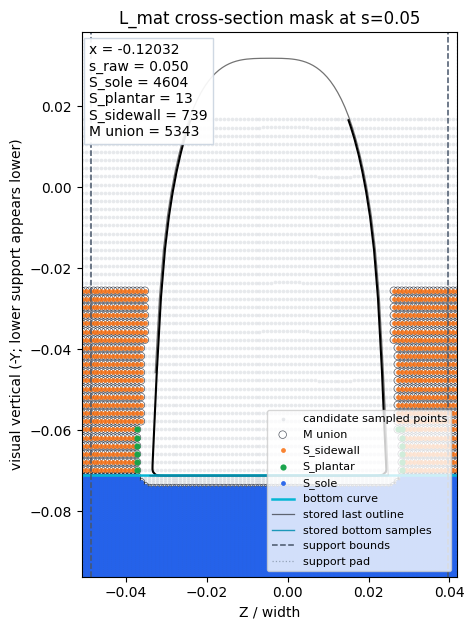

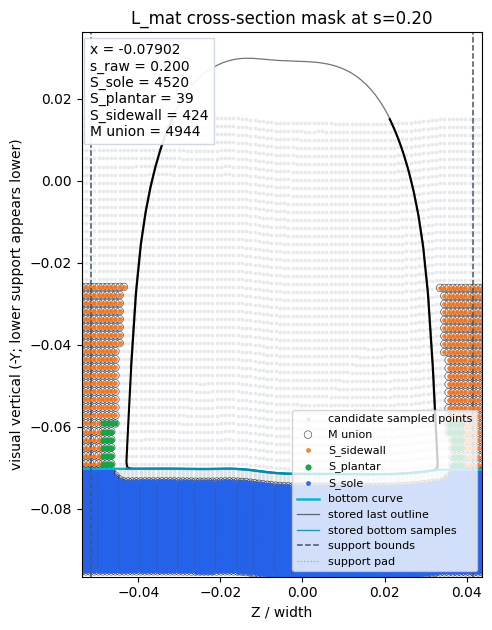

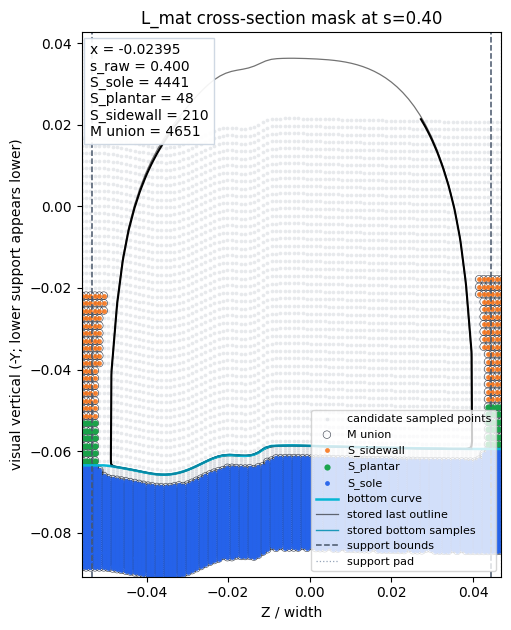

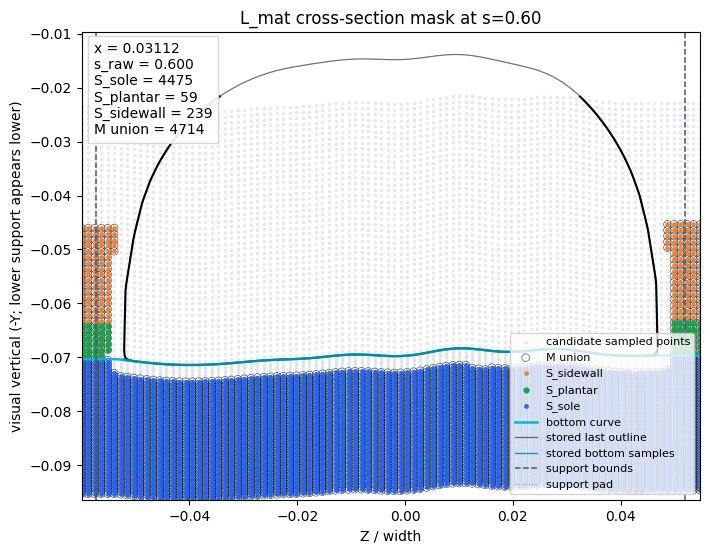

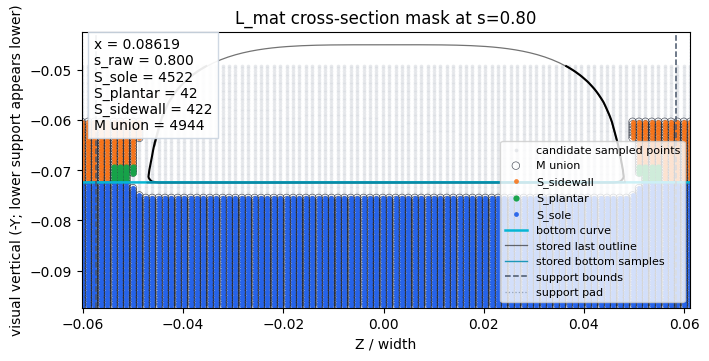

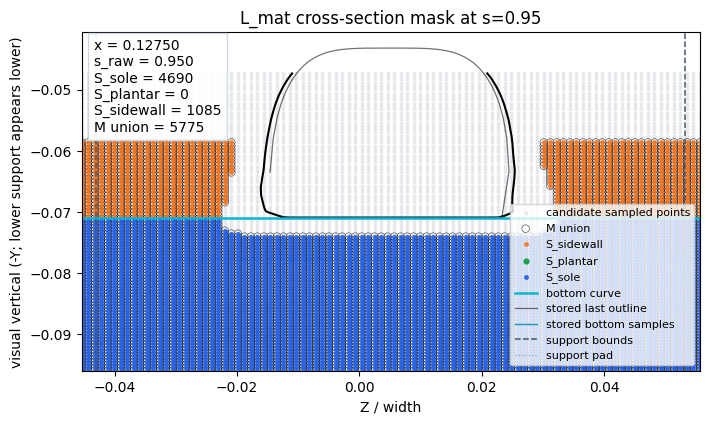

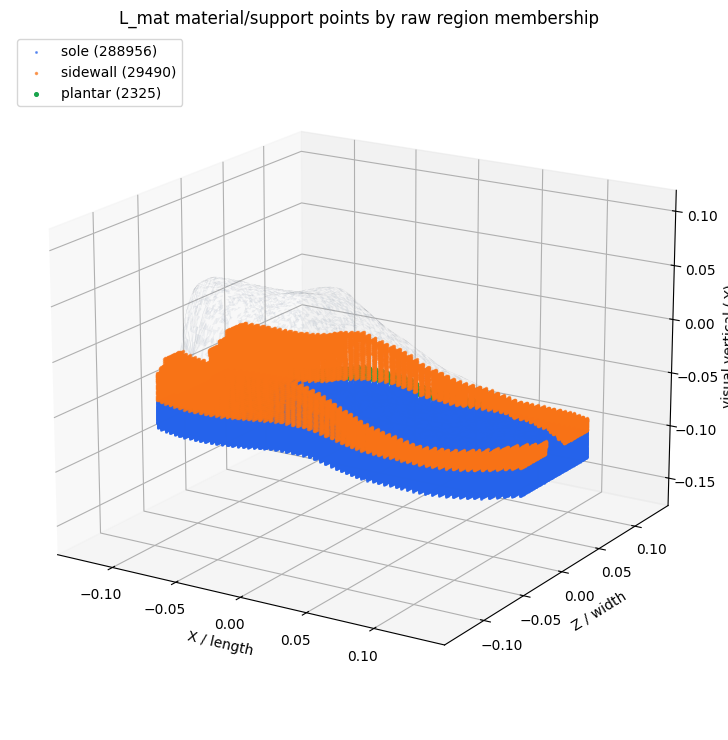

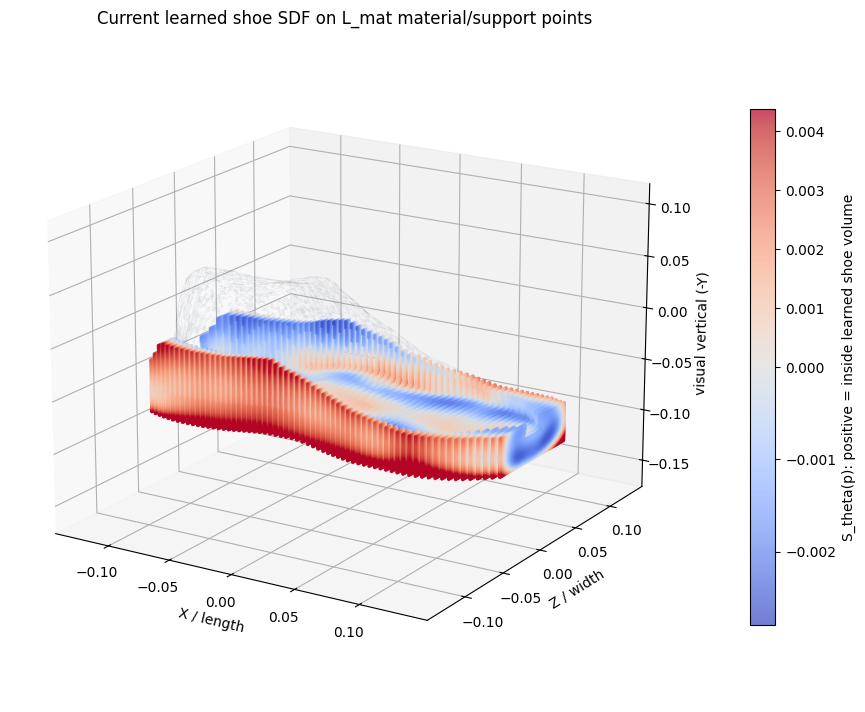

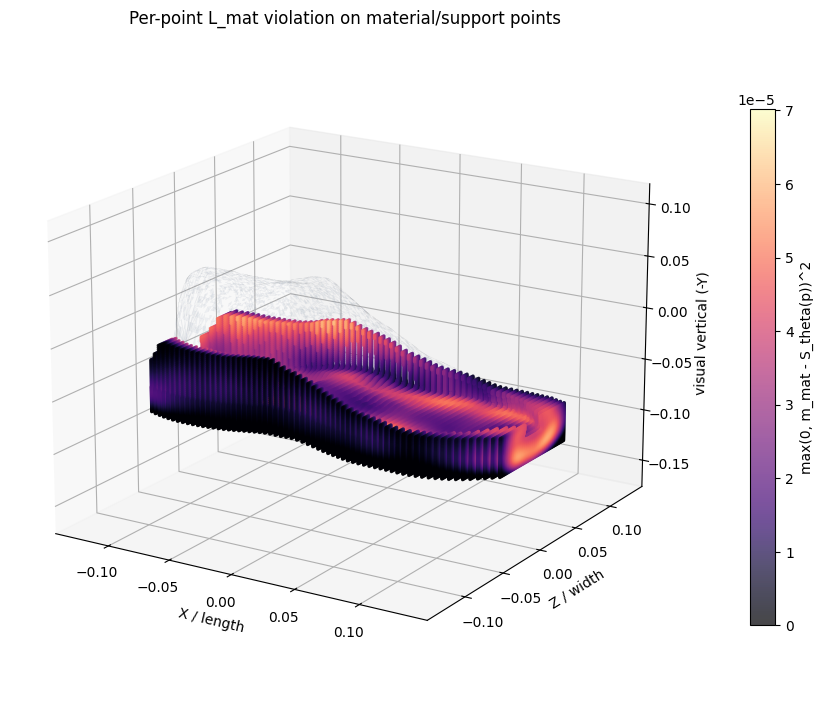

Saved L_mat visualizations:
  cross_section_masks: 6 files
  region_scatter_3d: /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/debug_xsec_lmat_visualization/material_points_by_region_3d.png
  sdf_value_scatter_3d: /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/debug_xsec_lmat_visualization/material_points_sdf_values_3d.png
  per_point_loss_scatter_3d: /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/debug_xsec_lmat_visualization/material_points_lmat_loss_3d.png
  summary_json: /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/debug_xsec_lmat_visualization/lmat_summary.json

Material SDF stats:
{
  "count": 318446,
  "fraction_sdf_positive": 0.2969828479553833,
  "fraction_sdf_ge_m_mat": 0.013653806296828976,
  "mean_sdf": -0.0004304638714529574,
  "min_sdf": -0.003945432603359222,
  "max_sdf": 0.010979630053043365,
  "p01_sdf": -0.0031019538640975953,
  "p50_sdf": -0.0008473135530948639,
  "p99_sdf": 0.0

In [5]:
lmat_material = lmat_material_union_with_regions(lmat_prior)
lmat_points = lmat_material['points']
lmat_regions = lmat_to_numpy(lmat_material['region_id']).astype(np.int64)
lmat_margin = float(lmat_prior.config.xsec_material_margin)

lmat_sdf_values = lmat_query_sdf(lmat_points)
lmat_losses = torch.relu(lmat_margin - lmat_sdf_values).square()
lmat_sdf_np = lmat_to_numpy(lmat_sdf_values)
lmat_loss_np = lmat_to_numpy(lmat_losses)

cross_section_paths = []
for s_value in LMAT_SLICE_S_VALUES:
    out_path = LMAT_DEBUG_DIR / f'cross_section_mask_s{s_value:.2f}.png'
    fig = lmat_plot_cross_section(lmat_prior, lmat_sections_npz, s_value, out_path=out_path)
    cross_section_paths.append(str(out_path))
    plt.show()

region_plot_path = LMAT_DEBUG_DIR / 'material_points_by_region_3d.png'
sdf_plot_path = LMAT_DEBUG_DIR / 'material_points_sdf_values_3d.png'
loss_plot_path = LMAT_DEBUG_DIR / 'material_points_lmat_loss_3d.png'

fig = lmat_plot_3d_regions(lmat_material, out_path=region_plot_path)
plt.show()

sdf_vmin = float(np.percentile(lmat_sdf_np, 2)) if lmat_sdf_np.size else -1.0
sdf_vmax = float(np.percentile(lmat_sdf_np, 98)) if lmat_sdf_np.size else 1.0
if not (sdf_vmin < 0.0 < sdf_vmax):
    sdf_abs = max(abs(sdf_vmin), abs(sdf_vmax), 1e-6)
    sdf_vmin, sdf_vmax = -sdf_abs, sdf_abs
sdf_norm = TwoSlopeNorm(vcenter=0.0, vmin=sdf_vmin, vmax=sdf_vmax)
fig = lmat_plot_3d_scalar(
    lmat_points,
    lmat_sdf_np,
    title='Current learned shoe SDF on L_mat material/support points',
    colorbar_label='S_theta(p): positive = inside learned shoe volume',
    cmap='coolwarm',
    norm=sdf_norm,
    out_path=sdf_plot_path,
)
plt.show()

loss_vmax = float(np.percentile(lmat_loss_np, 99.5)) if lmat_loss_np.size else 1.0
loss_vmax = max(loss_vmax, 1e-10)
loss_norm = Normalize(vmin=0.0, vmax=loss_vmax)
fig = lmat_plot_3d_scalar(
    lmat_points,
    lmat_loss_np,
    title='Per-point L_mat violation on material/support points',
    colorbar_label='max(0, m_mat - S_theta(p))^2',
    cmap='magma',
    norm=loss_norm,
    out_path=loss_plot_path,
)
plt.show()

unique_region_stats = {}
for rid, name in enumerate(LMAT_REGION_NAMES):
    mask = lmat_regions == rid
    vals = lmat_sdf_np[mask]
    losses = lmat_loss_np[mask]
    unique_region_stats[name] = {
        'count': int(mask.sum()),
        'mean_sdf': float(vals.mean()) if vals.size else 0.0,
        'mean_loss': float(losses.mean()) if losses.size else 0.0,
        'sum_loss': float(losses.sum()) if losses.size else 0.0,
        'max_loss': float(losses.max()) if losses.size else 0.0,
    }

training_group_stats = {
    'sole': lmat_group_stats('sole', lmat_prior.sole_points, lmat_margin),
    'plantar': lmat_group_stats('plantar', lmat_prior.plantar_points, lmat_margin),
    'sidewall': lmat_group_stats('sidewall', lmat_prior.sidewall_points, lmat_margin),
}
most_loss_unique = max(unique_region_stats.items(), key=lambda kv: kv[1]['sum_loss'])[0] if unique_region_stats else None
most_loss_training_groups = max(training_group_stats.items(), key=lambda kv: kv[1]['sum_loss'])[0] if training_group_stats else None

coords = lmat_material['coords']
h = lmat_to_numpy(coords['h'])
h_norm = lmat_to_numpy(coords['h_norm'])
s_raw = lmat_to_numpy(coords['s_raw'])
u_support = np.abs(lmat_to_numpy(coords['u_support']))
labels_on_m = lmat_material['labels']
sole_on_m = lmat_to_numpy(labels_on_m['sole_mask']).astype(bool)
plantar_on_m = lmat_to_numpy(labels_on_m['plantar_mask']).astype(bool)
sidewall_on_m = lmat_to_numpy(labels_on_m['sidewall_mask']).astype(bool)
raw_membership_counts_on_M = {
    'sole': int(sole_on_m.sum()),
    'plantar': int(plantar_on_m.sum()),
    'sidewall': int(sidewall_on_m.sum()),
}
overlap_counts_on_M = {
    'sole_and_plantar': int((sole_on_m & plantar_on_m).sum()),
    'sole_and_sidewall': int((sole_on_m & sidewall_on_m).sum()),
    'plantar_and_sidewall': int((plantar_on_m & sidewall_on_m).sum()),
    'all_three': int((sole_on_m & plantar_on_m & sidewall_on_m).sum()),
}

summary = {
    'shoe': LMAT_SHOE,
    'config_path': str(LMAT_CONFIG_PATH),
    'model_path': str(LMAT_MODEL_PATH),
    'pseudo_last_sdf_path': str(LMAT_PSEUDO_LAST_SDF_PATH),
    'pseudo_last_sections_path': str(LMAT_PSEUDO_LAST_SECTIONS_PATH),
    'pseudo_last_mesh_path': str(LMAT_PSEUDO_LAST_MESH_PATH),
    'debug_dir': str(LMAT_DEBUG_DIR),
    'material_margin_m_mat': lmat_margin,
    'counts': {
        'candidate_pool_total': int(lmat_prior.label_stats.get('xsec_pool_total_count', 0)),
        'material_union_M': int(lmat_points.shape[0]),
        'sole_mask_raw': int(lmat_prior.label_stats.get('xsec_sole_pool_count', 0)),
        'plantar_mask_raw': int(lmat_prior.label_stats.get('xsec_plantar_pool_count', 0)),
        'sidewall_mask_raw': int(lmat_prior.label_stats.get('xsec_sidewall_pool_count', 0)),
        'empty_pool': int(lmat_prior.label_stats.get('xsec_empty_pool_count', 0)),
    },
    'raw_membership_counts_on_M': raw_membership_counts_on_M,
    'overlap_counts_on_M': overlap_counts_on_M,
    'material_sdf_stats': {
        'count': int(lmat_sdf_np.size),
        'fraction_sdf_positive': float((lmat_sdf_np > 0.0).mean()) if lmat_sdf_np.size else 0.0,
        'fraction_sdf_ge_m_mat': float((lmat_sdf_np >= lmat_margin).mean()) if lmat_sdf_np.size else 0.0,
        'mean_sdf': float(lmat_sdf_np.mean()) if lmat_sdf_np.size else 0.0,
        'min_sdf': float(lmat_sdf_np.min()) if lmat_sdf_np.size else 0.0,
        'max_sdf': float(lmat_sdf_np.max()) if lmat_sdf_np.size else 0.0,
        'p01_sdf': float(np.percentile(lmat_sdf_np, 1)) if lmat_sdf_np.size else 0.0,
        'p50_sdf': float(np.percentile(lmat_sdf_np, 50)) if lmat_sdf_np.size else 0.0,
        'p99_sdf': float(np.percentile(lmat_sdf_np, 99)) if lmat_sdf_np.size else 0.0,
    },
    'material_loss_stats': {
        'mean_per_point_loss': float(lmat_loss_np.mean()) if lmat_loss_np.size else 0.0,
        'max_per_point_loss': float(lmat_loss_np.max()) if lmat_loss_np.size else 0.0,
        'sum_loss': float(lmat_loss_np.sum()) if lmat_loss_np.size else 0.0,
        'fraction_nonzero_loss': float((lmat_loss_np > 0.0).mean()) if lmat_loss_np.size else 0.0,
        'region_contributes_most_unique_union': most_loss_unique,
        'region_contributes_most_training_groups': most_loss_training_groups,
    },
    'material_geometry_stats': {
        'h_min': float(h.min()) if h.size else 0.0,
        'h_p50': float(np.percentile(h, 50)) if h.size else 0.0,
        'h_p99': float(np.percentile(h, 99)) if h.size else 0.0,
        'h_norm_min': float(h_norm.min()) if h_norm.size else 0.0,
        'h_norm_p50': float(np.percentile(h_norm, 50)) if h_norm.size else 0.0,
        'h_norm_p99': float(np.percentile(h_norm, 99)) if h_norm.size else 0.0,
        's_raw_min': float(s_raw.min()) if s_raw.size else 0.0,
        's_raw_max': float(s_raw.max()) if s_raw.size else 0.0,
        'abs_u_support_max': float(u_support.max()) if u_support.size else 0.0,
        'far_below_count_h_lt_minus_sole_depth': int((h < -float(lmat_prior.config.xsec_sole_depth)).sum()) if h.size else 0,
    },
    'unique_region_stats': unique_region_stats,
    'training_group_stats_overlap_counted_like_loss_sampling': training_group_stats,
    'saved_outputs': {
        'cross_section_masks': cross_section_paths,
        'region_scatter_3d': str(region_plot_path),
        'sdf_value_scatter_3d': str(sdf_plot_path),
        'per_point_loss_scatter_3d': str(loss_plot_path),
    },
}

summary_path = LMAT_DEBUG_DIR / 'lmat_summary.json'
summary['saved_outputs']['summary_json'] = str(summary_path)
with summary_path.open('w') as f:
    json.dump(summary, f, indent=2)

print('Saved L_mat visualizations:')
for key, value in summary['saved_outputs'].items():
    if isinstance(value, list):
        print(f'  {key}: {len(value)} files')
    else:
        print(f'  {key}: {value}')
print('\nMaterial SDF stats:')
print(json.dumps(summary['material_sdf_stats'], indent=2))
print('\nMaterial loss stats:')
print(json.dumps(summary['material_loss_stats'], indent=2))
print('\nTraining-group loss stats, overlap counted like sampled L_mat groups:')
print(json.dumps(training_group_stats, indent=2))
